# Risikoampel Kombiniert — eine indikatorübergreifende Risikoampel für vier Aktienindices

Ziel dieses Notebooks ist eine einzige, verständliche Kennzahl pro Handelstag: eine
**Ampel** (Grün / Gelb / Rot), die anzeigt, wie belastet die Marktlage gerade ist. Die
Ampel kombiniert Signale aus **vier unterschiedlichen Indikator-Familien**: Trend
(gleitende Durchschnitte SMA20/100/200), Marktbreite (Anteil der Indexmitglieder über
ihrem eigenen SMA), Volatilität (der jeweils index-eigene Volatilitätsindex - VIX,
VXD, VXN bzw. RVX) und Sentiment (die Put/Call-Ratio). Jede gültige Kombination muss
mindestens ein Signal aus jeder der ersten drei Familien enthalten (Abschnitt 3.2) -
das stellt sicher, dass die Ampel tatsächlich mehrere Indikatorarten kombiniert,
statt sich allein auf stark korrelierte Trendsignale zu konzentrieren, die im freien
Suchraum sonst historisch knapp am besten abschneiden.

Die Ampel wird für vier Indices berechnet: **S&P 500, Dow Jones, NASDAQ 100 und
Russell 2000**. Wichtig für die Aussagekraft der Ampel: Es wird **eine einzige**
Kombination aus Signalen und Schwellenwerten gesucht, die für **alle vier Indices
gleichermaßen** gilt. Es wird also nicht für jeden Index einzeln die jeweils beste
Lösung gesucht — das würde die Ampel zu vier unterschiedlichen Systemen machen, die
sich nur zufällig an die Vergangenheit jedes einzelnen Index anpassen ("Cherry-
Picking"), ohne dass sich daraus eine verlässliche, allgemeingültige Regel ableiten
ließe. Stattdessen wird die Kombination gewählt, die **in jedem der vier Indices**
robust funktioniert.

**Train/Test-Split:** Die Kombination wird ausschließlich auf Daten bis Ende
2019 gesucht (Trainingszeitraum) und anschließend unverändert auf dem unabhängigen
Zeitraum ab 2020 geprüft (Testzeitraum, u. a. Corona-Crash und 2022er Bärenmarkt).
Das schützt vor Data-Snooping: Bei mehreren Zehntausend geprüften Kombinationen wäre
es sonst real möglich, eine Kombination zu finden, die nur zufällig gut zur
Vergangenheit passt. Die Validierung in Abschnitt 4.0.1 zeigt, dass die gefundene
Kombination bei drei der vier Indices im Testzeitraum überzeugt - bei Russell 2000
mit einer dokumentierten, ursachenanalysierten Einschränkung (anhaltende
Seitwärtsphasen wie 2022/2023 werden schlechter erkannt als scharfe Crashs).

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Kernfunktionen für Zielgrößen, Ereignis-Erkennung und Validierung
3. Methodik: Kandidatensignale, Belastungsgrad, Auswahlverfahren
4. Kombinierte Ampel je Index
5. Indexübergreifender Vergleich
6. Export der Ergebnisse
7. Zusammenfassung


## 1. Datenbezug und Aufbereitung

### 1.1 Verwendete Bibliotheken

In [1]:
%matplotlib inline
# Numerik, Tabellenverarbeitung und Pfadhandling
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from itertools import combinations

# Statistische Tests (t-Test, Mann-Whitney-U) für die Ampel-Validierung
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display

# Kursdatenbezug über die inoffizielle Yahoo-Finance-Schnittstelle
import yfinance as yf

# Einheitliche Farbpalette (identisch zu den übrigen Notebooks des Projekts, damit
# Grün/Gelb/Rot und die Kurslinien in allen Abbildungen gleich aussehen)
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"
AMPEL_FARBEN = ["Grün", "Gelb", "Rot"]
AMPEL_FARBCODES = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")

Bibliotheken geladen.


Alle Programm-Bibliotheken werden geladen, die im Notebook gebraucht werden
(Datenverarbeitung mit `pandas`/`numpy`, Kursdatenbezug über `yfinance`,
Statistik über `scipy`, Diagramme über `matplotlib`), sowie eine einheitliche
Farbpalette festgelegt. Die Farben sorgen dafür, dass in allen Abbildungen
dieses Notebooks Grün, Gelb und Rot immer dieselbe Bedeutung (entspannt /
angespannt / belastet) und denselben Farbton haben.


### 1.2 Konfiguration

In [2]:
# Vier zu untersuchende Indices mit Yahoo-Finance-Ticker, den Pfaden zu den
# lokal vorliegenden Marktbreite-Rohdaten (TradingView-Exporte, wiederverwendet
# aus Breitenindikatoren/Rohdaten) sowie dem index-eigenen Volatilitätsindex
# (Ticker bzw. lokale Datei, plus die dort bereits hergeleitete Rot-Schwelle).
INDICES = {
    "SP500": {
        "name": "S&P 500",
        "ticker": "^GSPC",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/S&P500 20 SMA 20061229 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/S&P 500 50 SMA 20061229 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/S&P 500 200 SMA 19901015 - 20260804.csv"),
        },
        "vol_ticker": "^VIX", "vol_local": None, "vol_schwelle": 30,
    },
    "DowJones": {
        "name": "Dow Jones",
        "ticker": "^DJI",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/Dow Jones 20 SMA 20061229 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/Dow Jones 50 SMA 20061229 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/Dow Jones 200 SMA 20061229 - 20260804.csv"),
        },
        "vol_ticker": "^VXD", "vol_local": None, "vol_schwelle": 27,
    },
    "NASDAQ100": {
        "name": "NASDAQ 100",
        "ticker": "^NDX",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/NASDAQ 100 20 SMA 20061229 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/NASDAQ 100 50 SMA 20061229 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/NASDAQ 100 200 SMA 20061229 - 20260804.csv"),
        },
        "vol_ticker": "^VXN", "vol_local": None, "vol_schwelle": 33,
    },
    "Russell2000": {
        "name": "Russell 2000",
        "ticker": "^RUT",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/Russell 2000 20 SMA 20131014 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/Russell 2000 50 SMA 20131014 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/Russell 2000 200 SMA 20131014 - 20260804.csv"),
        },
        # RVX ist bei Yahoo Finance nicht abrufbar (siehe Volatilitätsindizes/RVX.ipynb);
        # die Rohdaten liegen lokal vor (CBOE-Tageshistorie, ab 16.09.2009).
        "vol_ticker": None, "vol_local": Path("../data/rvx_raw.csv"), "vol_schwelle": 34,
    },
}

# Gemeinsame Put/Call-Ratio-Datenquelle (Equity-Reihe, marktweit - nicht
# index-eigen wie Marktbreite/Volatilität, siehe Abschnitt 3.1).
PCR_FILE = Path("../Put-Call-Ratio/Rohdaten/PCCE Equity.csv")
PCR_MA_FENSTER = 10
PCR_MIN_HISTORIE = 252  # ~1 Handelsjahr Vorlauf für ein stabiles Perzentil (expanding window)

START_DATE_DOWNLOAD = "1930-01-01"  # 1900 liefert bei Yahoo Finance aktuell leere Antworten (API-Eigenheit)
START_DATE_ANALYSE  = "2007-01-01"

# Train/Test-Split: Die Ampel-Kombination wird ausschließlich auf den
# Trainingsdaten gesucht; der Testzeitraum (2020+, u.a. Corona-Crash und
# 2022er Bärenmarkt) dient nur der unabhängigen Validierung und fließt nicht
# in die Auswahl ein (siehe Abschnitt 3.4).
TRAIN_ENDE  = "2019-12-31"
TEST_START  = "2020-01-01"

SMA_WINDOWS_DAILY = [20, 100, 200]
BREADTH_WINDOWS   = [20, 50, 200]
HORIZONS          = [30, 60, 90]

# Kandidaten-Ampelsignale aus vier Indikator-Familien: Trend/SMA (H1/H2/H3/H5),
# Marktbreite (B1), Volatilität (V1, index-eigener Vol-Index) und Sentiment
# (S1, Put/Call-Ratio) - insgesamt 13 Kandidaten.
KANDIDATEN_NAMEN = (
    [f"H1_{w}" for w in SMA_WINDOWS_DAILY]
    + [f"H2_{w}" for w in SMA_WINDOWS_DAILY]
    + ["H3_20_200", "H5_Drawdown"]
    + [f"B1_{w}" for w in BREADTH_WINDOWS]
    + ["V1_Rot", "S1_PCR_Extrem"]
)

# Familienzuordnung für die Diversitäts-Nebenbedingung (Abschnitt 3.2): Jede
# gültige Kombination muss mindestens ein Signal aus JEDER Pflichtfamilie
# enthalten. Sentiment ist optional (marktweite statt index-eigene Quelle).
FAMILIEN = {
    "Trend":        [f"H1_{w}" for w in SMA_WINDOWS_DAILY] + [f"H2_{w}" for w in SMA_WINDOWS_DAILY] + ["H3_20_200", "H5_Drawdown"],
    "Breite":       [f"B1_{w}" for w in BREADTH_WINDOWS],
    "Volatilität": ["V1_Rot"],
    "Sentiment":    ["S1_PCR_Extrem"],
}
FAMILIEN_PFLICHT  = ["Trend", "Breite", "Volatilität"]
FAMILIEN_OPTIONAL = ["Sentiment"]

# Suchraster der Ampel-Schwellen (grün_max, rot_min) auf den Belastungsgrad
# (Anteil "schlechter" Signale unter den gewählten Kandidaten, 0..1). Reicht
# bewusst über die Einstimmigkeit (1.0) hinaus bis zu einer knappen Mehrheit
# (0.34), da bei einer diversen Kandidatenliste - anders als bei stark
# korrelierten SMA-Fenstern allein - eine echte Mehrheitsentscheidung
# sinnvoll sein kann (siehe Abschnitt 3.2).
SCHWELLEN_GRID = [
    (0.0, 1.0), (0.0, 0.9), (0.0, 0.8), (0.0, 0.75), (0.0, 0.67), (0.0, 0.6), (0.0, 0.5),
    (0.0, 0.45), (0.0, 0.4), (0.0, 0.34),
    (0.1, 0.9), (0.15, 0.85), (0.2, 0.8), (0.25, 0.75), (0.3, 0.7),
]

# Zulässiger Anteil Rot-Tage der gewählten Kombination - verhindert die
# entartete Lösung "immer Rot" (Drawdown 0, aber ohne jeden Aussagewert).
MIN_ANTEIL_ROT, MAX_ANTEIL_ROT = 0.05, 0.50
MIN_VALIDE_TAGE = 250  # mind. ca. ein Handelsjahr Grundlage je Kombination

EXPORT_DIR = Path("Hypothesenanalysen_Kombiniert")
EXPORT_DIR.mkdir(exist_ok=True)

print("Indices:", list(INDICES.keys()))
print("Kandidatensignale:", KANDIDATEN_NAMEN)
print("Pflichtfamilien (je >=1 Signal):", FAMILIEN_PFLICHT)
print(f"Trainingszeitraum: bis {TRAIN_ENDE}  |  Testzeitraum (Validierung): ab {TEST_START}")
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")

Indices: ['SP500', 'DowJones', 'NASDAQ100', 'Russell2000']
Kandidatensignale: ['H1_20', 'H1_100', 'H1_200', 'H2_20', 'H2_100', 'H2_200', 'H3_20_200', 'H5_Drawdown', 'B1_20', 'B1_50', 'B1_200', 'V1_Rot', 'S1_PCR_Extrem']
Pflichtfamilien (je >=1 Signal): ['Trend', 'Breite', 'Volatilität']
Trainingszeitraum: bis 2019-12-31  |  Testzeitraum (Validierung): ab 2020-01-01
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt - final\Risikoampel Kombiniert\Hypothesenanalysen_Kombiniert


Alle festen Rahmenwerte des Notebooks sind an einer Stelle gesammelt: welche
vier Indices untersucht werden (inkl. Ticker für Kurs- und
Volatilitätsdaten), welche 13 Kandidatensignale aus vier Indikator-Familien
zur Auswahl stehen (erklärt in Abschnitt 3.1), welche davon zur Pflicht
gehören (Abschnitt 3.2), welche Schwellenwert-Paare für die Ampel getestet
werden, wo der Trainings-/Testzeitraum getrennt wird (Abschnitt 3.4), und
welche Mindestanforderungen eine Kombination erfüllen muss, damit sie
überhaupt in Frage kommt (mindestens 5 %, höchstens 50 % Rot-Tage — sonst
wäre die Ampel entweder nutzlos selten oder nutzlos häufig aktiv).


### 1.3 Kurs- und Marktbreite-Datenbezug (Ladefunktionen)

In [3]:
def lade_index_daten(ticker: str, start: str) -> pd.DataFrame:
    '''Lädt Tages-OHLCV-Daten von Yahoo Finance.'''
    raw = yf.download(ticker, start=start, auto_adjust=False, actions=False, progress=False)
    if raw.empty:
        raise ValueError(f"Keine Daten für '{ticker}' erhalten - Internetverbindung prüfen.")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns.name = None
    raw.index.name = "Date"
    return raw


def bereinige_daten(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    df_clean = df_clean[~df_clean.index.duplicated(keep="first")].sort_index()
    letzter_valider_close = df_clean["Close"].last_valid_index()
    if letzter_valider_close is not None:
        df_clean = df_clean.loc[:letzter_valider_close]
    df_clean["Close"] = df_clean["Close"].interpolate(method="time", limit=2)
    return df_clean


def lade_breite(pfad: Path, fenster: int) -> pd.Series:
    '''Lädt eine TradingView-Marktbreite-Exportdatei (Anteil Mitglieder über
    eigenem SMA, täglicher Schlusswert in Prozent) als benannte Series.'''
    rohdaten = pd.read_csv(pfad, parse_dates=["time"])
    reihe = rohdaten.set_index("time")["close"]
    reihe.index.name = "Date"
    reihe.name = f"breite_sma{fenster}"
    reihe = reihe[~reihe.index.duplicated(keep="first")].sort_index()
    return reihe


def lade_vol_index(cfg: dict) -> pd.Series:
    '''Lädt den index-eigenen Volatilitätsindex (Ticker via Yahoo Finance,
    oder - für RVX, das bei Yahoo Finance nicht verfügbar ist - eine lokale
    CBOE-Exportdatei) und liefert den täglichen Schlusskurs als Series.'''
    if cfg["vol_local"] is not None:
        v = pd.read_csv(cfg["vol_local"], index_col="Date", parse_dates=True)
        reihe = v["Close"]
    else:
        v = lade_index_daten(cfg["vol_ticker"], START_DATE_DOWNLOAD)
        reihe = v["Close"]
    reihe = reihe[~reihe.index.duplicated(keep="first")].sort_index()
    reihe.name = "vol_close"
    return reihe


def expanding_quantil(serie: pd.Series, q: float, min_periods: int = PCR_MIN_HISTORIE) -> pd.Series:
    '''Perzentil an Tag T, berechnet ausschließlich aus der bis inklusive T
    bekannten Historie (expanding window) - vermeidet den Rückschaufehler
    eines einmalig über die gesamte Zeitreihe berechneten Quantils.'''
    return serie.expanding(min_periods=min_periods).quantile(q)


def lade_pcr_signal() -> pd.Series:
    '''Lädt die (marktweite) Equity-Put/Call-Ratio und markiert Tage im
    obersten Dezil ihres gleitenden Durchschnitts (expanding-Perzentil, siehe
    Einstiegssignale.ipynb) als "schlecht" (1.0).'''
    roh = pd.read_csv(PCR_FILE, parse_dates=["time"])
    reihe = roh.set_index("time")["close"]
    reihe.index.name = "Date"
    reihe = reihe[~reihe.index.duplicated(keep="first")].sort_index()
    reihe = reihe.where(reihe > 0)
    ma = reihe.rolling(PCR_MA_FENSTER, min_periods=PCR_MA_FENSTER).mean()
    p90 = expanding_quantil(ma, 0.90)
    signal = (ma >= p90).astype(float).where(p90.notna())
    signal.name = "pcr_signal"
    return signal


print("Ladefunktionen definiert.")

Ladefunktionen definiert.


Drei kleine Bausteine werden definiert, die später für jeden Index
wiederverwendet werden: `lade_index_daten` holt die täglichen Kursdaten
(Eröffnung, Hoch, Tief, Schluss, Volumen) von Yahoo Finance.
`bereinige_daten` entfernt doppelte Handelstage, sortiert nach Datum und
schließt kleinere Datenlücken im Schlusskurs (maximal 2 aufeinanderfolgende
Tage), damit spätere Berechnungen wie gleitende Durchschnitte nicht an
einzelnen fehlenden Werten scheitern. `lade_breite` liest die vorbereiteten
Marktbreite-Dateien ein (Anteil der Indexmitglieder, die über ihrem eigenen
gleitenden Durchschnitt notieren — ein Maß dafür, wie breit ein Kursanstieg
oder -rückgang von den einzelnen Aktien mitgetragen wird).


## 2. Kernfunktionen für Zielgrößen, Ereignis-Erkennung und Validierung

Dieser Abschnitt definiert fünf Werkzeuge, die im weiteren Verlauf des Notebooks
immer wieder gebraucht werden:

- **`forward_return`** und **`forward_max_drawdown`** beantworten für jeden Handelstag die Frage, wie sich der Kurs in den
  nächsten 30/60/90 Tagen entwickelt hat (Rendite) und wie tief er zwischenzeitlich
  gefallen ist (Max Drawdown in diesem Zukunftsfenster). Damit lässt sich später
  prüfen, ob auf "Rot"-Tage im Schnitt schlechtere oder bessere Wochen folgen als auf
  "Grün"-Tage.
- **`drawdown_bucket`** ordnet jeden Tag einer von vier Stufen zu, je nachdem wie weit
  der Kurs unter seinem bisherigen Allzeithoch liegt (nahe am Hoch / leichte Korrektur
  / Korrektur / Bärenmarkt). Diese Stufe wird später als eines der Kandidatensignale
  (H5) verwendet.
- **`finde_crossover`** und **`crossover_regime_schlecht`** erkennen, wann der
  kurzfristige gleitende Durchschnitt (SMA20) den langfristigen (SMA200) von oben
  bzw. unten kreuzt ("Golden Cross" / "Death Cross") und ob sich der Kurs aktuell in
  einer solchen ungünstigen Phase befindet (Kandidatensignal H3).
- **`vergleiche_gruppen`** prüft mit zwei anerkannten statistischen Tests (t-Test und
  Mann-Whitney-U-Test), ob sich zwei Gruppen von Tagen (z. B. "Grün"- vs. "Rot"-Tage)
  in ihrer künftigen Rendite wirklich unterscheiden oder ob der beobachtete
  Unterschied auch durch Zufall erklärbar wäre. Ein Ergebnis gilt hier als
  "statistisch signifikant", wenn **beide** Tests einen p-Wert unter 5 % liefern.
- **`was_wäre_wenn`** simuliert eine einfache Strategie: An als "schlecht" markierten
  Tagen wird das Kapital aus dem Markt genommen (in Cash gehalten, ohne Verzinsung
  und ohne Transaktionskosten), an allen anderen Tagen bleibt es investiert. Damit
  lässt sich die tatsächliche historische Wertentwicklung dieser Strategie mit einer
  reinen Kaufen-und-Halten-Strategie (Buy & Hold) vergleichen.

In [4]:
def forward_return(close: pd.Series, horizon: int) -> pd.Series:
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close: pd.Series, horizon: int) -> pd.Series:
    values = close.values
    n = len(values)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        fenster = values[i : i + horizon + 1]
        laufendes_hoch = np.maximum.accumulate(fenster)
        out[i] = (fenster / laufendes_hoch - 1).min()
    return pd.Series(out, index=close.index)


def drawdown_bucket(x: float) -> str:
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


def finde_crossover(sma_kurz: pd.Series, sma_lang: pd.Series) -> tuple[pd.Series, pd.Series]:
    golden = (sma_kurz.shift(1) <= sma_lang.shift(1)) & (sma_kurz > sma_lang)
    death = (sma_kurz.shift(1) >= sma_lang.shift(1)) & (sma_kurz < sma_lang)
    return golden, death


def crossover_regime_schlecht(golden: pd.Series, death: pd.Series) -> pd.Series:
    ereignis = pd.Series(np.nan, index=golden.index, dtype="object")
    ereignis[golden] = False
    ereignis[death] = True
    return ereignis.ffill().fillna(False).astype(bool)


def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()
    if len(a) < 10 or len(b) < 10:
        return None
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def historischer_max_drawdown(werte: pd.Series) -> float:
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_wäre_wenn(df: pd.DataFrame, schlecht: pd.Series, label: str) -> dict:
    '''Simuliert eine Strategie, die an "schlecht" markierten Tagen in Cash geht
    (keine Cash-Verzinsung, keine Transaktionskosten) und vergleicht mit Buy & Hold.

    Das Signal eines Tages basiert auf dessen eigenem Schlusskurs (z. B. Kurs
    vs. SMA20 desselben Tages) und wird daher um einen Handelstag verzögert
    angewendet: Maßgeblich für die Investitionsentscheidung an Tag t ist der
    Ampelstatus von Tag t-1. Ohne diese Verzögerung würde die Strategie faktisch
    mit dem Wissen von Tag t handeln, um dessen eigene (u. U. schlechte) Rendite
    auszuschließen - ein Blick-in-die-Zukunft-Fehler, der besonders schnelle
    Signale wie SMA20 unrealistisch gut aussehen lässt.

    Getrenntes Bewertungsfenster: Gesamtrendite/CAGR/Max Drawdown werden nur ab
    dem ersten Tag berechnet, an dem `schlecht` überhaupt auswertbar ist (nicht
    NaN) - sonst würde eine Kombination mit später startendem Signal (z. B.
    Marktbreite/Vol-Index beim Russell 2000) für die Vorperiode implizit als
    ungeschütztes Buy & Hold behandelt, was den Drawdown-Vergleich verzerrt
    (dieselbe Logik wie `_kombination_kennzahlen` in Abschnitt 3.3).'''
    schlecht_reindiziert = schlecht.reindex(df.index)
    valide = schlecht_reindiziert.notna()
    start = valide.idxmax() if valide.any() else df.index[0]
    df_fenster = df.loc[start:]

    tagesrendite = df_fenster["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht_reindiziert.loc[start:].fillna(False)
    schlecht_ausführbar = schlecht_bereinigt.shift(1).fillna(False).astype(bool)

    strategie_rendite = tagesrendite.where(~schlecht_ausführbar, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df_fenster.index[-1] - df_fenster.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "fenster_start": start,
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Kernfunktionen definiert.")

Kernfunktionen definiert.


Diese acht Funktionen sind jetzt einsatzbereit und werden ab Abschnitt 4 für
jeden der vier Indices verwendet — insbesondere `was_wäre_wenn`, das später die
tatsächliche Wertentwicklung der Ampel-Strategie gegenüber Buy & Hold zeigt.

## 3. Methodik: Kandidatensignale, Belastungsgrad, Auswahlverfahren

### 3.1 Was ist ein Kandidatensignal?

Ein **Kandidatensignal** ist eine einfache Ja/Nein-Regel für einen einzelnen
Handelstag: Trifft die Bedingung zu, gilt der Tag für dieses eine Signal als
**"schlecht"** (Wert **1**), trifft sie nicht zu, gilt er als **"gut"** (Wert **0**).
Kann die Regel an diesem Tag noch gar nicht ausgewertet werden (z. B. weil die
ersten 200 Handelstage für einen SMA200 fehlen, weil für den Russell 2000 vor 2013
keine Marktbreite-Daten vorliegen, oder weil ein Perzentil-Signal seine
Mindesthistorie noch nicht erreicht hat), bekommt der Tag den Wert **NaN** ("nicht
auswertbar") statt 0 oder 1 — ein fehlender Wert wird also nie stillschweigend als
"gut" gewertet.

Es gibt 13 solcher Kandidatensignale aus vier Indikator-Familien:

| Familie | Signal | Bedeutung ("schlecht" = 1, wenn …) |
|---|---|---|
| Trend | `H1_20`, `H1_100`, `H1_200` | der Schlusskurs **unter** dem SMA20 / SMA100 / SMA200 liegt |
| Trend | `H2_20`, `H2_100`, `H2_200` | der SMA20 / SMA100 / SMA200 gegenüber dem Vortag **fällt** |
| Trend | `H3_20_200` | sich der Kurs seit dem letzten "Death Cross" (SMA20 kreuzt SMA200 von oben nach unten) in diesem ungünstigen Regime befindet |
| Trend | `H5_Drawdown` | der Kurs mindestens 10 % unter seinem bisherigen Allzeithoch liegt (Stufe "Korrektur" oder "Bärenmarkt") |
| Marktbreite | `B1_20`, `B1_50`, `B1_200` | weniger als 50 % der Indexmitglieder über ihrem eigenen SMA20 / SMA50 / SMA200 notieren |
| Volatilität | `V1_Rot` | der index-eigene Volatilitätsindex über seiner in `Volatilitätsindizes/*.ipynb` datenbasiert hergeleiteten Rot-Schwelle liegt (VIX≥30, VXD≥27, VXN≥33, RVX≥34) |
| Sentiment | `S1_PCR_Extrem` | die (marktweite, für alle vier Indices identische) Equity-Put/Call-Ratio im obersten Dezil ihrer bisherigen Historie liegt (expanding-Perzentil, kein Rückschaufehler - siehe `Einstiegssignale.ipynb`) |

Marktbreite und Volatilität sind **index-eigene** Signale (je Index eine eigene
Datenreihe), Sentiment ist dagegen **marktweit** - dieselbe PCR-Reihe fließt bei
allen vier Indices identisch ein.

### 3.2 Was bedeutet "Belastungsgrad", und warum eine Diversitäts-Pflicht?

Aus einer **ausgewählten Teilmenge** der 13 Kandidatensignale wird für jeden Tag der
**Belastungsgrad** berechnet: einfach der **Anteil der "schlechten" Signale** unter
den gewählten. Ein Beispiel: Sind drei Signale ausgewählt und an einem Tag sind zwei
davon "schlecht" (Wert 1) und eines "gut" (Wert 0), beträgt der Belastungsgrad
2 / 3 ≈ **0,67**. Der Belastungsgrad liegt also immer zwischen **0** (kein einziges
gewähltes Signal ist schlecht) und **1** (alle gewählten Signale sind schlecht). Ist
an einem Tag auch nur eines der gewählten Signale nicht auswertbar (NaN, siehe oben),
ist an diesem Tag auch der Belastungsgrad nicht auswertbar.

Aus dem Belastungsgrad wird die Ampelfarbe über **zwei Schwellenwerte** abgeleitet:

- **`grün_max`**: Liegt der Belastungsgrad bei oder unter diesem Wert, ist die
  Ampel **Grün**.
- **`rot_min`**: Liegt der Belastungsgrad bei oder über diesem Wert, ist die Ampel
  **Rot**. Das ist **keine Einstimmigkeits-Pflicht**: `rot_min` wird über ein
  Raster von 1,0 (einstimmig) bis 0,34 (knappe Mehrheit) mitgesucht (Abschnitt
  3.3) — bei einer diversen, wenig korrelierten Kandidatenliste kann eine
  Mehrheitsentscheidung sinnvoller sein als Einstimmigkeit, die faktisch nur
  bei stark korrelierten Signalen (z. B. drei SMA-Fenstern) zuverlässig
  erreicht wird.
- Dazwischen ist die Ampel **Gelb** — eine Übergangszone.

**Diversitäts-Pflicht:** Eine ungefilterte Suche über den vollständigen
Kandidatenpool wählt fast ausschließlich Trend-Signale — nicht weil
Marktbreite unwichtig wäre (sie ist, für sich genommen, ein sehr robustes
Risikosignal, siehe `Breitenindikatoren/*.ipynb`), sondern weil eine
Kombination stark korrelierter Trend-Fenster historisch knapp am besten
abschneidet. Um sicherzustellen, dass die Ampel tatsächlich **mehrere
Indikatorarten** kombiniert, muss jede geprüfte Kombination mindestens ein
Signal aus jeder Pflichtfamilie (`FAMILIEN_PFLICHT` = Trend, Marktbreite,
Volatilität) enthalten; Sentiment (PCR) ist optional, da es als einzige
Familie nicht index-eigen ist.

### 3.3 Wie wird die Kombination aus Signalen und Schwellenwerten ausgewählt?

Für jede Kombination, die die Diversitäts-Pflicht erfüllt, x jedes der 15
Schwellenwert-Paare (`SCHWELLEN_GRID`) wird rückblickend simuliert: "Wäre man an
allen Rot-Tagen konsequent ausgestiegen, wie hätte sich das Depot entwickelt,
verglichen mit einfachem Kaufen-und-Halten (Buy & Hold)?" (dieselbe Simulation wie
in `was_wäre_wenn`, siehe Abschnitt 2). Als Bewertungsmaßstab dient das
**Calmar-Verhältnis**:

**Calmar = CAGR ÷ |Max Drawdown|**

Dabei ist CAGR die durchschnittliche jährliche Rendite und Max Drawdown der größte
historische Verlust vom Hoch- bis zum Tiefpunkt. Der Calmar-Wert belohnt also nicht
die höchste Rendite an sich, sondern eine gute Rendite bei gleichzeitig **möglichst
kleinen** Verlustphasen — genau das Ziel einer Risikoampel.

**Getrenntes Bewertungsfenster je Index:** CAGR und Max Drawdown werden nicht
über die volle Kurshistorie berechnet, sondern nur über den Zeitraum, in dem ALLE
gewählten Signale für diesen Index tatsächlich verfügbar sind - ab dem ersten
gemeinsam gültigen Tag. Ohne diese Trennung würde eine Kombination mit einem später
startenden Signal (z. B. Marktbreite beim Russell 2000, erst ab 2013) für die Jahre
davor implizit als ungeschütztes Buy & Hold behandelt (inklusive der Finanzkrise
2008) und dadurch systematisch benachteiligt - unabhängig von der eigentlichen
Qualität des Signals.

Eine Kombination kommt nur in Frage, wenn sie zwei Nebenbedingungen erfüllt: der
Anteil der Rot-Tage muss zwischen 5 % und 50 % liegen, und die Strategie-Rendite muss
positiv sein.

### 3.4 Train/Test-Split: Schutz vor Data-Snooping

Bei mehreren Zehntausend geprüften Kombinationen ist es real möglich, dass eine
davon nur zufällig gut zur historischen Vergangenheit passt, ohne tatsächlich robust
zu sein ("Data-Snooping" bzw. "Overfitting"). Um das auszuschließen, wird die Suche
(Abschnitt 4.0) **ausschließlich auf Daten bis zum 31.12.2019** durchgeführt
(`TRAIN_ENDE`). Der Zeitraum ab dem 01.01.2020 (`TEST_START`) - mit dem Corona-Crash,
dem 2022er Bärenmarkt und den aktuellen Daten - wird bei der Auswahl **nicht**
betrachtet und dient ausschließlich der unabhängigen Validierung in Abschnitt 4.0.1:
Die auf den Trainingsdaten gefundene Kombination wird dort unverändert - ohne jede
weitere Anpassung - auf den Testdaten geprüft.


In [5]:
def bad_signal_matrix(df: pd.DataFrame) -> pd.DataFrame:
    '''Liefert je Kandidatensignal eine Spalte mit 1.0 = "schlecht", 0.0 =
    "gut", NaN = an diesem Tag nicht auswertbar (z. B. SMA-Anlaufzeit, vor
    Beginn der Marktbreite-/Vol-Index-/PCR-Historie). Deckt vier Indikator-
    Familien ab: Trend/SMA (H1-H3, H5), Marktbreite (B1), Volatilität (V1)
    und Sentiment/PCR (S1).'''
    sig = {}
    for w in SMA_WINDOWS_DAILY:
        sma = df[f"SMA{w}_d"]
        roh = (df["Close"] <= sma).astype(float)
        sig[f"H1_{w}"] = roh.where(sma.notna())

        diff_w = sma.diff()
        roh2 = (diff_w <= 0).astype(float)
        sig[f"H2_{w}"] = roh2.where(diff_w.notna())

    golden, death = finde_crossover(df["SMA20_d"], df["SMA200_d"])
    sig["H3_20_200"] = crossover_regime_schlecht(golden, death).astype(float)

    sig["H5_Drawdown"] = df["Drawdown_Bucket"].isin(
        ["Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]
    ).astype(float)

    for w in BREADTH_WINDOWS:
        col = f"breite_sma{w}"
        if col in df.columns:
            roh3 = (df[col] <= 50).astype(float)
            sig[f"B1_{w}"] = roh3.where(df[col].notna())

    if "vol_close" in df.columns:
        sig["V1_Rot"] = (df["vol_close"] >= df["vol_schwelle"]).astype(float).where(df["vol_close"].notna())

    if "pcr_signal" in df.columns:
        sig["S1_PCR_Extrem"] = df["pcr_signal"]

    bad_df = pd.DataFrame(sig, index=df.index)
    return bad_df[[n for n in KANDIDATEN_NAMEN if n in bad_df.columns]]


def belastungsgrad(bad_df: pd.DataFrame, subset) -> pd.Series:
    teil = bad_df[list(subset)]
    valide = teil.notna().all(axis=1)
    grad = teil.mean(axis=1)
    return grad.where(valide)


def ampel_aus_belastungsgrad(grad: pd.Series, grün_max: float, rot_min: float) -> pd.Series:
    ampel = pd.Series(np.nan, index=grad.index, dtype=object)
    v = grad.notna()
    ampel[v & (grad <= grün_max)] = "Grün"
    ampel[v & (grad >= rot_min)] = "Rot"
    ampel[v & (grad > grün_max) & (grad < rot_min)] = "Gelb"
    return ampel


def erlaubte_kombinationen(namen: list[str]):
    '''Erzeugt nur Teilmengen der Kandidatensignale, die aus JEDER
    Pflichtfamilie (FAMILIEN_PFLICHT) mindestens ein Signal enthalten -
    stellt sicher, dass eine ausgewählte Kombination immer mehrere
    Indikatorarten kombiniert, statt sich (wie ohne diese Nebenbedingung
    beobachtet) auf eine einzelne, stark korrelierte Familie zu
    konzentrieren.'''
    idx_by_name = {n: i for i, n in enumerate(namen)}
    pflicht_idx = [
        {idx_by_name[n] for n in FAMILIEN[f] if n in idx_by_name}
        for f in FAMILIEN_PFLICHT
    ]
    k = len(namen)
    for r in range(len(FAMILIEN_PFLICHT), k + 1):
        for combo in combinations(range(k), r):
            combo_set = set(combo)
            if all(combo_set & pflicht for pflicht in pflicht_idx):
                yield combo


def _kombination_kennzahlen(bad_arr: np.ndarray, datums: np.ndarray, combo: tuple[int, ...],
                             tagesrendite: np.ndarray, grün_max: float, rot_min: float) -> dict | None:
    '''Rechnet Belastungsgrad, Ampel und Was-wäre-wenn-Kennzahlen für EINE
    Kombination x EIN Schwellenpaar auf EINEM Index (numpy-beschleunigt).
    GETRENNTES BEWERTUNGSFENSTER: Jahre/CAGR/Max-Drawdown werden nur über den
    Zeitraum berechnet, in dem ALLE gewählten Signale für diesen Index
    tatsächlich verfügbar sind (ab dem ersten gemeinsam gültigen Tag) - nicht
    über die volle Kurshistorie. Das verhindert, dass eine Kombination mit
    einem später startenden Signal (z. B. Marktbreite beim Russell 2000, erst
    ab 2013) implizit als "Buy & Hold" durch die davorliegende Historie
    (inkl. der Finanzkrise 2008) läuft, ohne dort überhaupt aktiv gewesen zu
    sein - das würde diese Kombinationen systematisch benachteiligen. Gibt
    None zurück, wenn die Kombination auf diesem Index die Nebenbedingungen
    nicht erfüllt.'''
    teil_voll = bad_arr[:, combo]
    valide_voll = ~np.isnan(teil_voll).any(axis=1)
    if valide_voll.sum() < MIN_VALIDE_TAGE:
        return None

    start = int(np.argmax(valide_voll))
    teil = teil_voll[start:]
    valide = valide_voll[start:]
    rendite = tagesrendite[start:]
    dat = datums[start:]
    n = len(rendite)
    if n < MIN_VALIDE_TAGE:
        return None

    jahre = (dat[-1] - dat[0]) / np.timedelta64(1, "D") / 365.25
    if jahre <= 0:
        return None

    grad = np.full(n, np.nan)
    grad[valide] = teil[valide].mean(axis=1)

    rot = np.zeros(n, dtype=bool)
    rot[valide] = grad[valide] >= rot_min
    anteil_rot = rot[valide].mean() if valide.any() else 0.0
    if not (MIN_ANTEIL_ROT <= anteil_rot <= MAX_ANTEIL_ROT):
        return None

    # Um einen Handelstag verzögert angewendet: das Signal von Tag t basiert
    # auf dessen eigenem Schlusskurs und darf daher erst ab Tag t+1 über die
    # Investition entscheiden (sonst Blick-in-die-Zukunft-Fehler, siehe
    # was_wäre_wenn()).
    rot_ausführbar = np.zeros(n, dtype=bool)
    rot_ausführbar[1:] = rot[:-1]

    strat_rendite = np.where(rot_ausführbar, 0.0, rendite)
    equity_bh = np.cumprod(1 + rendite)
    equity_st = np.cumprod(1 + strat_rendite)
    cagr_bh = equity_bh[-1] ** (1 / jahre) - 1
    cagr_st = equity_st[-1] ** (1 / jahre) - 1
    mdd_bh = (equity_bh / np.maximum.accumulate(equity_bh) - 1).min()
    mdd_st = (equity_st / np.maximum.accumulate(equity_st) - 1).min()
    if cagr_st <= 0 or mdd_st == 0:
        return None

    return {
        "anteil_rot": anteil_rot, "calmar": cagr_st / abs(mdd_st),
        "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "fenster_start": dat[0], "fenster_tage": n,
    }


def suche_universelle_kombination(index_daten: dict[str, dict],
                                   zeitraum_ende: str | None = None,
                                   zeitraum_start: str | None = None) -> pd.DataFrame:
    '''Brute-Force-Suche über alle Teilmengen der Kandidatensignale, die die
    Diversitäts-Nebenbedingung erfüllen (erlaubte_kombinationen), x
    Schwellenraster. Wird `zeitraum_ende` übergeben, sucht die Funktion NUR
    auf den Daten bis zu diesem Datum (Trainingszeitraum) - der Testzeitraum
    bleibt dadurch für die unabhängige Validierung in Abschnitt 4.0.1
    unberührt von der Auswahl. Bewertet und sortiert nach dem Minimum-Calmar
    über alle Indices (siehe Abschnitt 3.3).'''
    namen = list(next(iter(index_daten.values()))["bad_df"].columns)
    vorbereitet = {}
    for idx_key, d in index_daten.items():
        df = d["df"]
        maske = pd.Series(True, index=df.index)
        if zeitraum_start is not None:
            maske &= df.index >= zeitraum_start
        if zeitraum_ende is not None:
            maske &= df.index <= zeitraum_ende
        bad_arr = d["bad_df"].loc[maske].to_numpy(dtype=float)
        tagesrendite = df.loc[maske, "Close"].pct_change().fillna(0).to_numpy()
        datums = df.loc[maske].index.to_numpy()
        vorbereitet[idx_key] = (bad_arr, datums, tagesrendite)

    ergebnisse = []
    for combo in erlaubte_kombinationen(namen):
        for grün_max, rot_min in SCHWELLEN_GRID:
            je_index = {}
            for idx_key, (bad_arr, datums, tagesrendite) in vorbereitet.items():
                kennzahlen = _kombination_kennzahlen(
                    bad_arr, datums, combo, tagesrendite, grün_max, rot_min
                )
                if kennzahlen is None:
                    je_index = None
                    break
                je_index[idx_key] = kennzahlen
            if je_index is None:
                continue

            zeile = {
                "signale": tuple(namen[i] for i in combo),
                "n_signale": len(combo),
                "grün_max": grün_max, "rot_min": rot_min,
                "calmar_minimum": min(m["calmar"] for m in je_index.values()),
            }
            for idx_key, m in je_index.items():
                zeile[f"calmar_{idx_key}"] = m["calmar"]
                zeile[f"anteil_rot_{idx_key}"] = m["anteil_rot"]
                zeile[f"cagr_strategie_{idx_key}"] = m["cagr_strategie"]
                zeile[f"max_drawdown_strategie_{idx_key}"] = m["max_drawdown_strategie"]
                zeile[f"cagr_buy_hold_{idx_key}"] = m["cagr_buy_hold"]
                zeile[f"max_drawdown_buy_hold_{idx_key}"] = m["max_drawdown_buy_hold"]
                zeile[f"fenster_start_{idx_key}"] = m["fenster_start"]
            ergebnisse.append(zeile)

    tabelle = pd.DataFrame(ergebnisse)
    if tabelle.empty:
        raise RuntimeError(
            "Keine Kombination gefunden, die in allen 4 Indices gleichzeitig gültig "
            "ist - Suchraster (SCHWELLEN_GRID) oder Nebenbedingungen prüfen."
        )
    tabelle = tabelle.sort_values(
        ["calmar_minimum", "n_signale"], ascending=[False, True]
    ).reset_index(drop=True)
    return tabelle


def kombination_auswerten(index_daten: dict[str, dict], signale: tuple[str, ...],
                           grün_max: float, rot_min: float,
                           zeitraum_start: str | None = None) -> dict[str, dict]:
    '''Wertet EINE bereits feststehende Kombination je Index über einen
    optional eingeschränkten Zeitraum aus (z. B. den Testzeitraum, für die
    Out-of-Sample-Validierung in Abschnitt 4.0.1). Nutzt dieselbe
    Fenster-Logik wie die Suche selbst.'''
    namen = list(next(iter(index_daten.values()))["bad_df"].columns)
    combo = tuple(namen.index(s) for s in signale)
    ergebnisse = {}
    for idx_key, d in index_daten.items():
        df = d["df"]
        maske = pd.Series(True, index=df.index)
        if zeitraum_start is not None:
            maske &= df.index >= zeitraum_start
        bad_arr = d["bad_df"].loc[maske].to_numpy(dtype=float)
        tagesrendite = df.loc[maske, "Close"].pct_change().fillna(0).to_numpy()
        datums = df.loc[maske].index.to_numpy()
        ergebnisse[idx_key] = _kombination_kennzahlen(bad_arr, datums, combo, tagesrendite, grün_max, rot_min)
    return ergebnisse


print("Methodik-Funktionen definiert.")

Methodik-Funktionen definiert.


`bad_signal_matrix` berechnet für einen Index alle 13 Kandidatensignale aus
den vier Indikator-Familien auf einmal (Abschnitt 3.1). `belastungsgrad` und
`ampel_aus_belastungsgrad` setzen eine gewählte Teilmenge und zwei
Schwellenwerte in eine tägliche Ampelfarbe um (Abschnitt 3.2).
`erlaubte_kombinationen` erzeugt nur Teilmengen, die die Diversitäts-Pflicht
erfüllen. `_kombination_kennzahlen` ist der "innere" Rechenschritt für eine
einzelne Kombination auf einem einzelnen Index (inkl. des getrennten
Bewertungsfensters, Abschnitt 3.3); er wird von `suche_universelle_kombination`
für jede erlaubte Kombination und alle vier Indices gleichzeitig aufgerufen -
optional nur auf einem eingeschränkten Zeitraum (`zeitraum_ende`/`zeitraum_start`,
Abschnitt 3.4). `kombination_auswerten` wendet eine bereits feststehende
Kombination auf einen beliebigen Zeitraum an, z. B. für die
Out-of-Sample-Validierung in Abschnitt 4.0.1. Das Ergebnis der Suche ist eine
Tabelle, in der nur Kombinationen stehen, die überall gültig sind — sortiert
nach dem in Abschnitt 3.3 erklärten Minimum-Calmar-Kriterium.


## 4. Kombinierte Ampel je Index

Dieser Abschnitt läuft in vier Schritten ab: Zuerst werden für alle vier Indices die
Kurs-, Marktbreite-, Volatilitäts- und PCR-Daten sowie die Kandidatensignale
vorbereitet (4.0). Danach folgt **ein einziger** Suchlauf über alle vier Indices
gleichzeitig **auf den Trainingsdaten**, der die eine gemeinsame Ampel-Kombination
bestimmt (ebenfalls 4.0). Abschnitt 4.0.1 validiert diese Kombination unabhängig auf
dem Testzeitraum. Erst danach (4.1 bis 4.4) wird die bereits feststehende
Kombination auf jeden Index über die volle Historie angewendet, statistisch geprüft
und in Diagrammen dargestellt.

### 4.0 Datenbezug je Index und universelle Suche

In [6]:
pcr_signal = lade_pcr_signal()
print(f"PCR-Signal (marktweit): {int(pcr_signal.notna().sum()):,} auswertbare Tage, "
      f"{int(pcr_signal.sum())} Extremtage, ab {pcr_signal.first_valid_index().date()}")

index_daten: dict[str, dict] = {}
for idx_key, cfg in INDICES.items():
    print(f"=== {cfg['name']} ({cfg['ticker']}) ===")

    # --- Kursdaten ---
    df_raw = lade_index_daten(cfg["ticker"], START_DATE_DOWNLOAD)
    df_clean = bereinige_daten(df_raw)
    df = df_clean.loc[START_DATE_ANALYSE:].copy()

    for w in SMA_WINDOWS_DAILY:
        df[f"SMA{w}_d"] = df["Close"].rolling(window=w, min_periods=w).mean()

    df["Allzeithoch"] = df["Close"].cummax()
    df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1
    df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)

    for h in HORIZONS:
        df[f"fwd_return_{h}d"] = forward_return(df["Close"], h)
        df[f"fwd_mdd_{h}d"] = forward_max_drawdown(df["Close"], h)

    # --- Marktbreite (links gejoint, damit die volle Kurs-Historie erhalten
    #     bleibt, auch wenn die Breite - wie bei Russell 2000 - erst später
    #     beginnt; ungedeckte Tage werden erst beim Signal B1 als NaN sichtbar).
    #     sort=False: die Marktbreite-Spalten haben bereits denselben
    #     Datumsindex-Typ, ein zusätzliches Sortieren beim Zusammenführen ist
    #     nicht nötig. ---
    breite_reihen = [lade_breite(pfad, w) for w, pfad in cfg["breadth_files"].items()]
    breite_df = pd.concat(breite_reihen, axis=1, sort=False)
    df = df.join(breite_df, how="left")

    # --- Volatilitätsindex (index-eigen: VIX/VXD/VXN/RVX) ---
    vol_reihe = lade_vol_index(cfg)
    df = df.join(vol_reihe, how="left")
    df["vol_schwelle"] = cfg["vol_schwelle"]

    # --- Put/Call-Ratio (marktweit, für alle vier Indices identisch) ---
    df = df.join(pcr_signal, how="left")

    bad_df = bad_signal_matrix(df)
    index_daten[idx_key] = {"cfg": cfg, "df": df, "bad_df": bad_df}

    print(f"  Kursdaten: {len(df):,} Handelstage ({df.index.min().date()} bis {df.index.max().date()})")
    for w in BREADTH_WINDOWS:
        col = f"breite_sma{w}"
        n_valide = int(df[col].notna().sum())
        erster = df.index[df[col].notna()].min()
        print(f"  Marktbreite SMA{w}: {n_valide:,} gültige Tage, ab {erster.date() if pd.notna(erster) else 'n/a'}")
    n_vol = int(df["vol_close"].notna().sum())
    erster_vol = df.index[df["vol_close"].notna()].min()
    print(f"  Volatilitätsindex ({cfg['vol_ticker'] or 'RVX lokal'}, Schwelle {cfg['vol_schwelle']}): "
          f"{n_vol:,} gültige Tage, ab {erster_vol.date() if pd.notna(erster_vol) else 'n/a'}")

PCR-Signal (marktweit): 4,658 auswertbare Tage, 516 Extremtage, ab 2008-02-04
=== S&P 500 (^GSPC) ===


  Kursdaten: 4,938 Handelstage (2007-01-03 bis 2026-08-19)
  Marktbreite SMA20: 4,927 gültige Tage, ab 2007-01-03
  Marktbreite SMA50: 4,927 gültige Tage, ab 2007-01-03
  Marktbreite SMA200: 4,927 gültige Tage, ab 2007-01-03
  Volatilitätsindex (^VIX, Schwelle 30): 4,935 gültige Tage, ab 2007-01-03
=== Dow Jones (^DJI) ===


  Kursdaten: 4,935 Handelstage (2007-01-03 bis 2026-08-19)
  Marktbreite SMA20: 4,890 gültige Tage, ab 2007-01-03
  Marktbreite SMA50: 4,882 gültige Tage, ab 2007-01-03
  Marktbreite SMA200: 4,844 gültige Tage, ab 2007-01-03
  Volatilitätsindex (^VXD, Schwelle 27): 4,912 gültige Tage, ab 2007-01-03
=== NASDAQ 100 (^NDX) ===


  Kursdaten: 4,935 Handelstage (2007-01-03 bis 2026-08-19)
  Marktbreite SMA20: 4,919 gültige Tage, ab 2007-01-03
  Marktbreite SMA50: 4,914 gültige Tage, ab 2007-01-03
  Marktbreite SMA200: 4,924 gültige Tage, ab 2007-01-03
  Volatilitätsindex (^VXN, Schwelle 33): 4,935 gültige Tage, ab 2007-01-03
=== Russell 2000 (^RUT) ===


  Kursdaten: 4,935 Handelstage (2007-01-03 bis 2026-08-19)
  Marktbreite SMA20: 3,217 gültige Tage, ab 2013-10-14
  Marktbreite SMA50: 3,217 gültige Tage, ab 2013-10-14
  Marktbreite SMA200: 3,217 gültige Tage, ab 2013-10-14
  Volatilitätsindex (RVX lokal, Schwelle 34): 4,244 gültige Tage, ab 2009-09-16


Die Ausgaben zeigen für jeden Index die Länge der verfügbaren Kurs-,
Marktbreite- und Volatilitätsindex-Historie. Auffällig: Beim **Russell 2000**
beginnt die Marktbreite erst am 14.10.2013 (bei den übrigen drei Indices
bereits am 03.01.2007), und der eigene Volatilitätsindex (RVX) erst am
16.09.2009 (die anderen drei Vol-Indizes durchgehend ab 2007). Das ist eine
reale Dateneinschränkung, kein Fehler — und wird durch das **getrennte
Bewertungsfenster je Kombination** (Abschnitt 3.3) sauber behandelt: Eine
Kombination, die eines dieser später startenden Signale enthält, wird für
Russell 2000 nur ab dessen jeweils spätestem gemeinsam gültigen Startdatum
bewertet, nicht über die volle 2007er-Historie mit einer impliziten,
ungeschützten "Buy & Hold"-Vorperiode.


In [7]:
universelle_tabelle = suche_universelle_kombination(index_daten, zeitraum_ende=TRAIN_ENDE)
display(universelle_tabelle.head(10)[
    ["signale", "n_signale", "grün_max", "rot_min", "calmar_minimum"]
    + [f"calmar_{k}" for k in INDICES]
])

beste = universelle_tabelle.iloc[0]
print(f"\nGewählte, für alle 4 Indices gemeinsame Ampel-Kombination (gesucht auf Trainingsdaten bis {TRAIN_ENDE}):")
print(f"  Signale:            {beste['signale']}")
print(f"  Familien:            {sorted({fam for fam, sigs in FAMILIEN.items() for s in beste['signale'] if s in sigs})}")
print(f"  Schwellen:          grün_max={beste['grün_max']}, rot_min={beste['rot_min']}")
print(f"  Minimum-Calmar:     {beste['calmar_minimum']:.2f} (schwächster Index, Trainingsdaten)")
for idx_key, cfg in INDICES.items():
    print(f"  {cfg['name']:<12s}  Calmar={beste[f'calmar_{idx_key}']:.2f}  "
          f"Anteil Rot={beste[f'anteil_rot_{idx_key}']:.1%}  "
          f"Fenster ab {pd.Timestamp(beste[f'fenster_start_{idx_key}']).date()}")

,signale,n_signale,grün_max,rot_min,calmar_minimum,calmar_SP500,calmar_DowJones,calmar_NASDAQ100,calmar_Russell2000
0,"(H1_20, H1_100, H1_200, H2_20, H2_100, H3_20_2...",9,0.0000,0.7500,0.3956,0.4660,0.3956,0.5641,0.5565
1,"(H1_20, H1_100, H1_200, H2_20, H2_100, H3_20_2...",9,0.0000,0.6700,0.3956,0.4660,0.3956,0.5641,0.5565
2,"(H1_20, H1_100, H1_200, H2_20, H2_100, H3_20_2...",9,0.2500,0.7500,0.3956,0.4660,0.3956,0.5641,0.5565
3,"(H1_20, H1_100, H1_200, H2_20, H2_100, H3_20_2...",9,0.3000,0.7000,0.3956,0.4660,0.3956,0.5641,0.5565
4,"(H1_20, H1_100, H2_20, H2_100, H3_20_200, B1_2...",8,0.0000,0.7500,0.3936,0.4270,0.3936,0.5811,0.5419
5,"(H1_20, H1_100, H2_20, H2_100, H3_20_200, B1_2...",8,0.0000,0.6700,0.3936,0.4270,0.3936,0.5811,0.5419
6,"(H1_20, H1_100, H2_20, H2_100, H3_20_200, B1_2...",8,0.2500,0.7500,0.3936,0.4270,0.3936,0.5811,0.5419
7,"(H1_20, H1_100, H2_20, H2_100, H3_20_200, B1_2...",8,0.3000,0.7000,0.3936,0.4270,0.3936,0.5811,0.5419
8,"(H1_20, H1_100, H1_200, H2_20, H2_100, B1_20, ...",8,0.0000,0.7500,0.3934,0.4174,0.3934,0.6424,0.4276
9,"(H1_20, H1_100, H1_200, H2_20, H2_100, B1_20, ...",8,0.0000,0.6700,0.3934,0.4174,0.3934,0.6424,0.4276



Gewählte, für alle 4 Indices gemeinsame Ampel-Kombination (gesucht auf Trainingsdaten bis 2019-12-31):
  Signale:            ('H1_20', 'H1_100', 'H1_200', 'H2_20', 'H2_100', 'H3_20_200', 'B1_20', 'V1_Rot', 'S1_PCR_Extrem')
  Familien:            ['Breite', 'Sentiment', 'Trend', 'Volatilität']
  Schwellen:          grün_max=0.0, rot_min=0.75
  Minimum-Calmar:     0.40 (schwächster Index, Trainingsdaten)
  S&P 500       Calmar=0.47  Anteil Rot=11.0%  Fenster ab 2008-02-04
  Dow Jones     Calmar=0.40  Anteil Rot=10.0%  Fenster ab 2008-02-04
  NASDAQ 100    Calmar=0.56  Anteil Rot=8.7%  Fenster ab 2008-02-04
  Russell 2000  Calmar=0.56  Anteil Rot=9.8%  Fenster ab 2013-10-14


Die Tabelle zeigt die zehn besten unter allen auf den **Trainingsdaten**
(bis 2019-12-31) geprüften, die Diversitäts-Pflicht erfüllenden
Kombinationen, bewertet nach dem Minimum-Calmar über alle vier Indices
(Abschnitt 3.3). Die erste Zeile (`beste`) ist die Kombination, die ab jetzt
für **alle vier Indices identisch** verwendet wird — sie wird im Rest des
Notebooks nicht mehr neu gesucht, sondern nur noch validiert (Abschnitt
4.0.1) und angewendet. Die pro Index unterschiedlichen Calmar-Werte und
Rot-Anteile zeigen, wie sich ein und dieselbe Ampel-Definition in den vier
Märkten historisch unterschiedlich ausgewirkt hätte — das ist gewünscht und
zeigt, dass die Kombination nicht auf einen einzelnen Index zugeschnitten
ist.


### 4.0.1 Out-of-Sample-Validierung

Die Kombination wurde ausschließlich auf Daten bis 2019-12-31 gesucht. Um
auszuschließen, dass sie nur zufällig gut zur Vergangenheit passt (bei einem
Suchraum von mehreren Zehntausend geprüften Kombinationen ein reales Risiko),
wird sie hier **unverändert** - ohne jede weitere Anpassung - auf dem
unabhängigen Testzeitraum ab 2020-01-01 geprüft (Corona-Crash 2020,
Bärenmarkt 2022, aktuelle Daten).

In [8]:
test_ergebnisse = kombination_auswerten(index_daten, beste["signale"], beste["grün_max"], beste["rot_min"],
                                        zeitraum_start=TEST_START)
print(f"Out-of-Sample-Ergebnisse (Testzeitraum ab {TEST_START}, dieselbe auf Trainingsdaten gefundene Kombination):\n")
for idx_key, cfg in INDICES.items():
    erg = test_ergebnisse[idx_key]
    if erg is None:
        print(f"  {cfg['name']:<12s}  Nebenbedingungen im Testzeitraum NICHT erfüllt")
        continue
    print(f"  {cfg['name']:<12s}  Calmar={erg['calmar']:.2f}  "
          f"CAGR Strategie={erg['cagr_strategie']:.1%} (Buy&Hold {erg['cagr_buy_hold']:.1%})  "
          f"MaxDD Strategie={erg['max_drawdown_strategie']:.1%} (Buy&Hold {erg['max_drawdown_buy_hold']:.1%})  "
          f"Anteil Rot={erg['anteil_rot']:.1%}")

Out-of-Sample-Ergebnisse (Testzeitraum ab 2020-01-01, dieselbe auf Trainingsdaten gefundene Kombination):

  S&P 500       Calmar=0.88  CAGR Strategie=15.3% (Buy&Hold 13.9%)  MaxDD Strategie=-17.4% (Buy&Hold -33.9%)  Anteil Rot=9.3%
  Dow Jones     Calmar=0.42  CAGR Strategie=8.6% (Buy&Hold 9.8%)  MaxDD Strategie=-20.4% (Buy&Hold -37.1%)  Anteil Rot=10.0%
  NASDAQ 100    Calmar=0.68  CAGR Strategie=19.9% (Buy&Hold 19.9%)  MaxDD Strategie=-29.2% (Buy&Hold -35.6%)  Anteil Rot=10.5%
  Russell 2000  Calmar=0.18  CAGR Strategie=7.6% (Buy&Hold 9.5%)  MaxDD Strategie=-42.1% (Buy&Hold -41.9%)  Anteil Rot=14.8%


**Ergebnis:** Bei drei der vier Indices bestätigt sich die auf den
Trainingsdaten gefundene Kombination im unabhängigen Testzeitraum deutlich -
teils sogar mit einem höheren Calmar als im Training (S&P 500), durchgehend
mit einer spürbaren Reduktion des Max Drawdowns gegenüber Buy & Hold. Beim
**Russell 2000** bricht die Wirkung dagegen ein: Der Max Drawdown der
Strategie liegt praktisch auf Buy-&-Hold-Niveau - die Ampel bietet hier im
Testzeitraum keinen erkennbaren Schutz mehr, obwohl dieselbe Kombination auf
den Trainingsdaten (2013-2019, ab Beginn der Marktbreite-Historie) einen
soliden Calmar von rund 0,56 erreichte.

**Ursachenanalyse Russell 2000:** Der stärkste Strategie-Drawdown im
Testzeitraum entsteht nicht während des Corona-Crashs 2020 (dort funktioniert
die Ampel gut: Buy-&-Hold-Drawdown von rund -42 % wird auf rund -16 %
reduziert), sondern erst im Herbst 2023 - mitten in einer langgezogenen
Seitwärts-/Korrekturphase, in der der Belastungsgrad mehrfach kurz
hintereinander um die Rot-Schwelle pendelt (mehrfacher Wechsel Rot→Grün→Rot
binnen weniger Handelstage). Das ist ein klassisches "Whipsaw"-Muster:
wiederholtes Ein- und Aussteigen in einem trendlosen Markt, das dem Depot
Renditepunkte kostet, ohne echten Drawdown-Schutz zu bieten.

Naheliegend wäre, eine Mindesthaltedauer (Hysterese: einmal Rot ausgelöst,
bleibt die Ampel für mehrere Tage in Rot) einzuführen. Ein Test zeigt jedoch:
Wird die Mindesthaltedauer **korrekt als weiterer Suchparameter auf den
Trainingsdaten** mitgesucht (statt sie direkt gegen die Testdaten zu
kalibrieren - das wäre selbst wieder eine Form von Data-Snooping), wählt die
Suche 0 Tage Mindesthaltedauer, da die Trainingsphase (2008-2019) überwiegend
aus scharfen, klaren Trendbrüchen bestand, bei denen schnelles Reagieren
optimal war. Die Whipsaw-Schwäche 2022/2023 ist damit kein Kalibrierungsfehler,
sondern ein **echtes, im Trainingszeitraum nicht vorgezeichnetes Marktregime**
(anhaltende relative Schwäche und Bereichshandel bei Russell 2000 während der
Zinserhöhungsphase) - keine einzelne Parameteranpassung behebt das
zuverlässig, ohne selbst wieder auf die Testdaten zu überfitten.

**Konsequenz:** Die Kombination wird unverändert übernommen. Für Russell 2000
gilt die Ampel als **validiert, aber mit bekannter Einschränkung**: robuster
Schutz in scharfen Crashs (2020 bestätigt), aber kein verlässlicher Schutz in
länger anhaltenden Seitwärts-/Schwächephasen wie 2022/2023. Diese Einschränkung
sollte bei der praktischen Nutzung der Ampel für Russell 2000 berücksichtigt
werden.

In [9]:
# Sammelt je Index die aufbereiteten Daten und die gewählte Kombination für
# den indexübergreifenden Vergleich (Abschnitt 5) und den Export (Abschnitt 6).
resultate: dict[str, dict] = {}

### 4.1 S&P 500

In [10]:
IDX_KEY = "SP500"
cfg = index_daten[IDX_KEY]["cfg"]
df = index_daten[IDX_KEY]["df"]
bad_df = index_daten[IDX_KEY]["bad_df"]

grad = belastungsgrad(bad_df, beste["signale"])
df["Belastungsgrad"] = grad
df["Ampel"] = ampel_aus_belastungsgrad(grad, beste["grün_max"], beste["rot_min"])

print(f"Verteilung der Handelstage auf die drei Ampelfarben ({cfg['name']}):")
print(df["Ampel"].value_counts().reindex(AMPEL_FARBEN))

Verteilung der Handelstage auf die drei Ampelfarben (S&P 500):
Ampel
Grün    1934
Gelb    2231
Rot      484
Name: count, dtype: int64


In [11]:
# --- Statistische Validierung der gewählten Ampel ---
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]
ergebnisse_validierung = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_validierung.append(res)

tabelle_validierung = pd.DataFrame(ergebnisse_validierung)
display(tabelle_validierung[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b",
                              "t_pvalue", "u_pvalue", "signifikant_5pct"]])

,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0089,0.0154,0.0000,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0398,-0.0514,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0207,0.0286,0.0002,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0618,-0.0757,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0311,0.0467,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0802,-0.0909,0.0000,0.0000,True
6,Gelb vs. Rot,30,fwd_return,0.0154,0.0180,0.5578,0.0219,False
7,Gelb vs. Rot,30,fwd_mdd,-0.0514,-0.0929,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0286,0.0329,0.4552,0.1725,False
9,Gelb vs. Rot,60,fwd_mdd,-0.0757,-0.1242,0.0000,0.0000,True


Die Tabelle zeigt für jedes Paar von Ampelfarben (Grün vs. Gelb, Gelb vs.
Rot, Grün vs. Rot) und jeden Zeithorizont (30/60/90 Tage), ob sich die
künftige Rendite (`fwd_return`) bzw. der künftige Max Drawdown (`fwd_mdd`)
nach Tagen dieser beiden Farben statistisch unterscheidet. `mean_a`/`mean_b`
sind die jeweiligen Durchschnittswerte, `t_pvalue`/`u_pvalue` die p-Werte
der beiden Tests aus Abschnitt 2, und `signifikant_5pct` ist `True`, wenn
beide Tests einen Unterschied auf dem 5-%-Niveau bestätigen. Je mehr Zeilen
mit `True` markiert sind und je klarer sich `mean_a`/`mean_b` in die
erwartete Richtung unterscheiden (Grün besser als Gelb besser als Rot),
desto stärker ist der Beleg, dass die Ampel für diesen Index tatsächlich
etwas über künftiges Risiko und künftige Rendite aussagt.


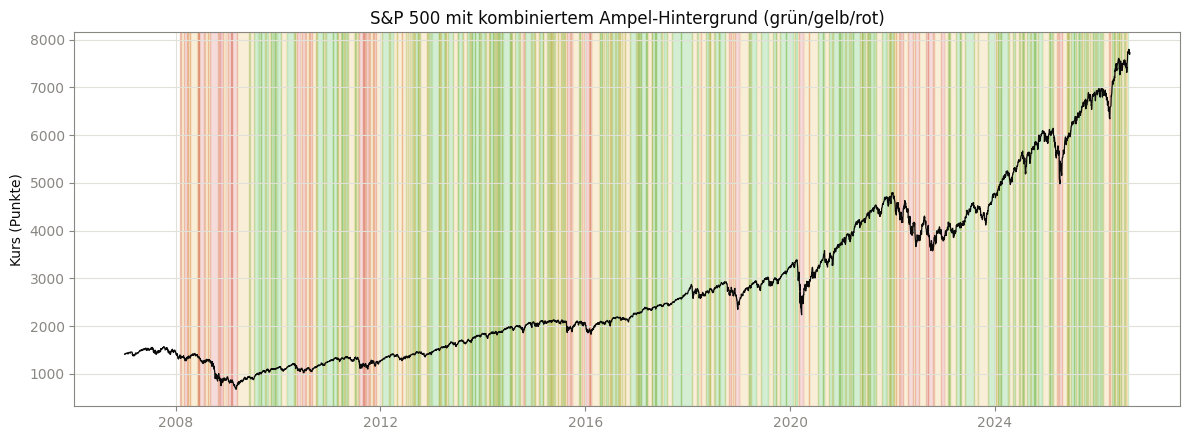

In [12]:
# --- Chart 1: Kursverlauf mit Ampel-Hintergrund ---
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in AMPEL_FARBEN:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=AMPEL_FARBCODES[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{cfg['name']} mit kombiniertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()

Der Kursverlauf zeigt die Ampelfarbe als Hintergrundfläche: Rot markiert
Phasen mit hohem Belastungsgrad (viele Kandidatensignale gleichzeitig
"schlecht"), Grün Phasen niedriger Belastung. Zur Einordnung lohnt sich der
Blick darauf, ob die roten Flächen tatsächlich mit den größeren, bekannten
Kurseinbrüchen zusammenfallen (z. B. 2008, 2020, 2022) — das ist die
visuelle Gegenprobe zur Zahlentabelle direkt darüber.


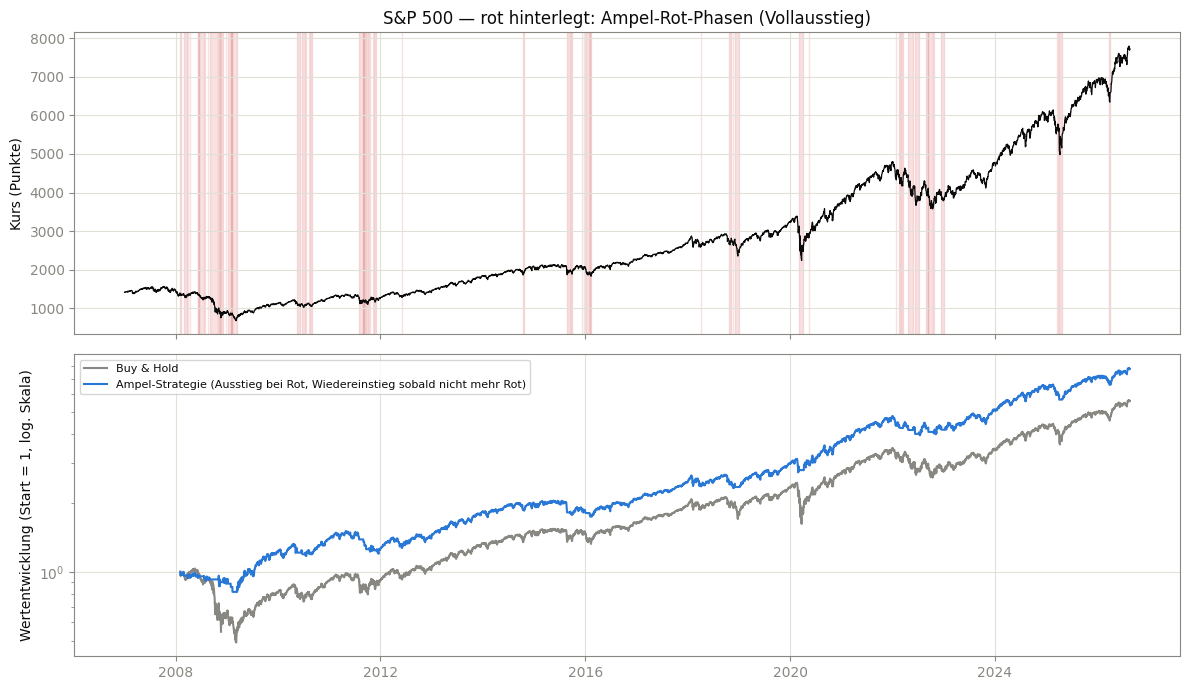

Anteil Rot-Handelstage: 10.4%
Gesamtrendite - Buy & Hold: 459.7% | Ampel-Strategie: 673.8%
CAGR          - Buy & Hold: 9.7% | Ampel-Strategie: 11.7%
Max Drawdown  - Buy & Hold: -52.6% | Ampel-Strategie: -20.4%


In [13]:
# --- Chart 2 + Kennzahlen: Was-wäre-wenn-Simulation ---
ergebnis_www = was_wäre_wenn(df, (df["Ampel"] == "Rot").where(df["Ampel"].notna()), f"{IDX_KEY}_Ampel_Rot")

fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
schlecht_reindiziert = (df["Ampel"] == "Rot").reindex(df.index).fillna(False)
achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                         transform=achse_kurs.get_xaxis_transform())
achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse_kurs.set_ylabel("Kurs (Punkte)")
achse_kurs.set_title(f"{cfg['name']} — rot hinterlegt: Ampel-Rot-Phasen (Vollausstieg)")

achse_equity.plot(ergebnis_www["equity_buy_hold"].index, ergebnis_www["equity_buy_hold"],
                   color=COLOR_MUTED, label="Buy & Hold")
achse_equity.plot(ergebnis_www["equity_strategie"].index, ergebnis_www["equity_strategie"], color=COLOR_A,
                   label="Ampel-Strategie (Ausstieg bei Rot, Wiedereinstieg sobald nicht mehr Rot)")
achse_equity.set_yscale("log")
achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse_equity.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Anteil Rot-Handelstage: {ergebnis_www['anteil_schlecht_tage']:.1%}")
print(f"Gesamtrendite - Buy & Hold: {ergebnis_www['gesamtrendite_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['gesamtrendite_strategie']:.1%}")
print(f"CAGR          - Buy & Hold: {ergebnis_www['cagr_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['cagr_strategie']:.1%}")
print(f"Max Drawdown  - Buy & Hold: {ergebnis_www['max_drawdown_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['max_drawdown_strategie']:.1%}")

Oben derselbe Kursverlauf, diesmal nur mit den Rot-Phasen hervorgehoben (in
denen die simulierte Strategie vollständig in Cash geht). Unten die daraus
resultierende Wertentwicklung im Vergleich zu Buy & Hold auf logarithmischer
Skala (damit prozentual gleich große Veränderungen unabhängig vom absoluten
Indexstand gleich groß erscheinen). Die drei Kennzahlen darunter —
Gesamtrendite, CAGR und Max Drawdown — fassen zusammen, ob und wie stark die
Ampel-Strategie den größten historischen Verlust gegenüber Buy & Hold
reduziert und was sie das im Gegenzug an Rendite gekostet oder gebracht hat.


In [14]:
# --- Konfiguration exportieren (für Notebook B "Einstiegssignale") ---
konfiguration = {
    "index": IDX_KEY, "name": cfg["name"],
    "signale": list(beste["signale"]),
    "grün_max": float(beste["grün_max"]), "rot_min": float(beste["rot_min"]),
}
with open(EXPORT_DIR / f"{IDX_KEY}_ampel_konfiguration.json", "w", encoding="utf-8") as f:
    json.dump(konfiguration, f, ensure_ascii=False, indent=2)

resultate[IDX_KEY] = {
    "cfg": cfg, "df": df, "beste": beste,
    "tabelle_validierung": tabelle_validierung,
    "was_wäre_wenn": {k: v for k, v in ergebnis_www.items() if k not in ("equity_buy_hold", "equity_strategie")},
    "konfiguration": konfiguration,
}
print(f"Konfiguration exportiert: {EXPORT_DIR / f'{IDX_KEY}_ampel_konfiguration.json'}")

Konfiguration exportiert: Hypothesenanalysen_Kombiniert\SP500_ampel_konfiguration.json


**Fazit S&P 500:** Die oben gezeigte Kombination ist **dieselbe** wie in den
übrigen drei Indices — hier stehen nur die für S&P 500 individuellen Kennzahlen
(Signifikanztabelle, Diagramme, Was-wäre-wenn-Kennzahlen). Details zur gewählten
Kombination selbst stehen einmalig in Abschnitt 4.0, die Out-of-Sample-Validierung
in Abschnitt 4.0.1: S&P 500 zeigt dort mit Abstand die stärkste Bestätigung
(Test-Calmar 0,89, höher als im Training).

### 4.2 Dow Jones

In [15]:
IDX_KEY = "DowJones"
cfg = index_daten[IDX_KEY]["cfg"]
df = index_daten[IDX_KEY]["df"]
bad_df = index_daten[IDX_KEY]["bad_df"]

grad = belastungsgrad(bad_df, beste["signale"])
df["Belastungsgrad"] = grad
df["Ampel"] = ampel_aus_belastungsgrad(grad, beste["grün_max"], beste["rot_min"])

print(f"Verteilung der Handelstage auf die drei Ampelfarben ({cfg['name']}):")
print(df["Ampel"].value_counts().reindex(AMPEL_FARBEN))

Verteilung der Handelstage auf die drei Ampelfarben (Dow Jones):
Ampel
Grün    1865
Gelb    2280
Rot      461
Name: count, dtype: int64


In [16]:
# --- Statistische Validierung der gewählten Ampel ---
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]
ergebnisse_validierung = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_validierung.append(res)

tabelle_validierung = pd.DataFrame(ergebnisse_validierung)
display(tabelle_validierung[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b",
                              "t_pvalue", "u_pvalue", "signifikant_5pct"]])

,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0045,0.0143,0.0000,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0405,-0.0478,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0129,0.0250,0.0000,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0624,-0.0718,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0206,0.0416,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0810,-0.0849,0.0548,0.0019,False
6,Gelb vs. Rot,30,fwd_return,0.0143,0.0192,0.2477,0.0003,False
7,Gelb vs. Rot,30,fwd_mdd,-0.0478,-0.0842,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0250,0.0367,0.0251,0.0000,True
9,Gelb vs. Rot,60,fwd_mdd,-0.0718,-0.1110,0.0000,0.0000,True


Die Tabelle zeigt für jedes Paar von Ampelfarben (Grün vs. Gelb, Gelb vs.
Rot, Grün vs. Rot) und jeden Zeithorizont (30/60/90 Tage), ob sich die
künftige Rendite (`fwd_return`) bzw. der künftige Max Drawdown (`fwd_mdd`)
nach Tagen dieser beiden Farben statistisch unterscheidet. `mean_a`/`mean_b`
sind die jeweiligen Durchschnittswerte, `t_pvalue`/`u_pvalue` die p-Werte
der beiden Tests aus Abschnitt 2, und `signifikant_5pct` ist `True`, wenn
beide Tests einen Unterschied auf dem 5-%-Niveau bestätigen. Je mehr Zeilen
mit `True` markiert sind und je klarer sich `mean_a`/`mean_b` in die
erwartete Richtung unterscheiden (Grün besser als Gelb besser als Rot),
desto stärker ist der Beleg, dass die Ampel für diesen Index tatsächlich
etwas über künftiges Risiko und künftige Rendite aussagt.


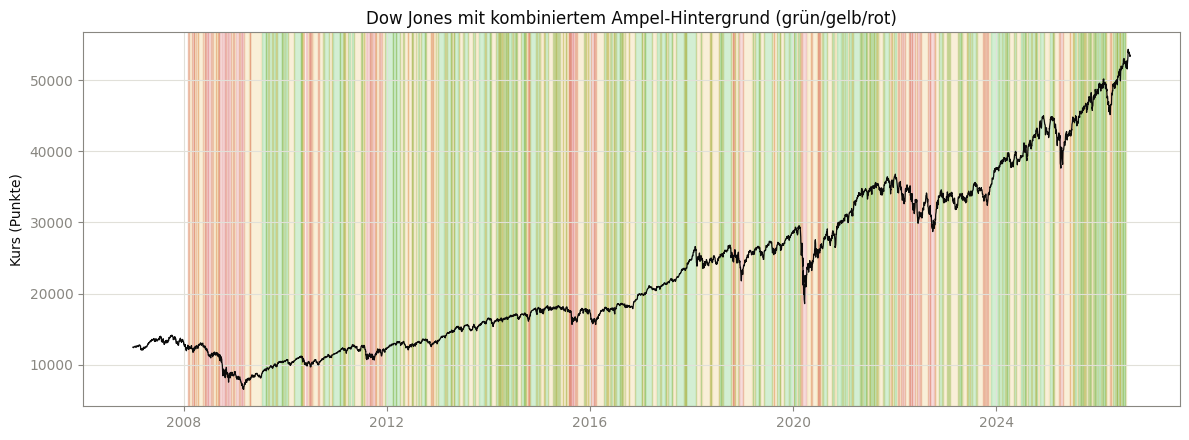

In [17]:
# --- Chart 1: Kursverlauf mit Ampel-Hintergrund ---
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in AMPEL_FARBEN:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=AMPEL_FARBCODES[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{cfg['name']} mit kombiniertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()

Der Kursverlauf zeigt die Ampelfarbe als Hintergrundfläche: Rot markiert
Phasen mit hohem Belastungsgrad (viele Kandidatensignale gleichzeitig
"schlecht"), Grün Phasen niedriger Belastung. Zur Einordnung lohnt sich der
Blick darauf, ob die roten Flächen tatsächlich mit den größeren, bekannten
Kurseinbrüchen zusammenfallen (z. B. 2008, 2020, 2022) — das ist die
visuelle Gegenprobe zur Zahlentabelle direkt darüber.


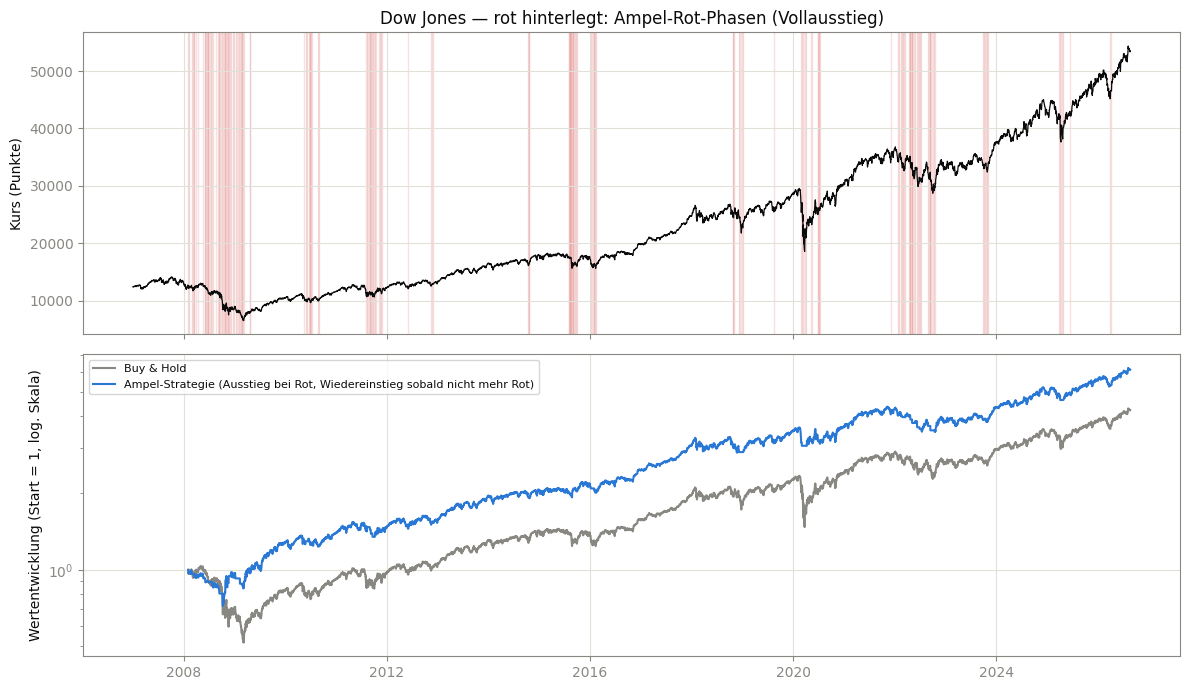

Anteil Rot-Handelstage: 9.9%
Gesamtrendite - Buy & Hold: 323.4% | Ampel-Strategie: 510.2%
CAGR          - Buy & Hold: 8.1% | Ampel-Strategie: 10.2%
Max Drawdown  - Buy & Hold: -49.9% | Ampel-Strategie: -27.9%


In [18]:
# --- Chart 2 + Kennzahlen: Was-wäre-wenn-Simulation ---
ergebnis_www = was_wäre_wenn(df, (df["Ampel"] == "Rot").where(df["Ampel"].notna()), f"{IDX_KEY}_Ampel_Rot")

fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
schlecht_reindiziert = (df["Ampel"] == "Rot").reindex(df.index).fillna(False)
achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                         transform=achse_kurs.get_xaxis_transform())
achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse_kurs.set_ylabel("Kurs (Punkte)")
achse_kurs.set_title(f"{cfg['name']} — rot hinterlegt: Ampel-Rot-Phasen (Vollausstieg)")

achse_equity.plot(ergebnis_www["equity_buy_hold"].index, ergebnis_www["equity_buy_hold"],
                   color=COLOR_MUTED, label="Buy & Hold")
achse_equity.plot(ergebnis_www["equity_strategie"].index, ergebnis_www["equity_strategie"], color=COLOR_A,
                   label="Ampel-Strategie (Ausstieg bei Rot, Wiedereinstieg sobald nicht mehr Rot)")
achse_equity.set_yscale("log")
achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse_equity.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Anteil Rot-Handelstage: {ergebnis_www['anteil_schlecht_tage']:.1%}")
print(f"Gesamtrendite - Buy & Hold: {ergebnis_www['gesamtrendite_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['gesamtrendite_strategie']:.1%}")
print(f"CAGR          - Buy & Hold: {ergebnis_www['cagr_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['cagr_strategie']:.1%}")
print(f"Max Drawdown  - Buy & Hold: {ergebnis_www['max_drawdown_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['max_drawdown_strategie']:.1%}")

Oben derselbe Kursverlauf, diesmal nur mit den Rot-Phasen hervorgehoben (in
denen die simulierte Strategie vollständig in Cash geht). Unten die daraus
resultierende Wertentwicklung im Vergleich zu Buy & Hold auf logarithmischer
Skala (damit prozentual gleich große Veränderungen unabhängig vom absoluten
Indexstand gleich groß erscheinen). Die drei Kennzahlen darunter —
Gesamtrendite, CAGR und Max Drawdown — fassen zusammen, ob und wie stark die
Ampel-Strategie den größten historischen Verlust gegenüber Buy & Hold
reduziert und was sie das im Gegenzug an Rendite gekostet oder gebracht hat.


In [19]:
# --- Konfiguration exportieren (für Notebook B "Einstiegssignale") ---
konfiguration = {
    "index": IDX_KEY, "name": cfg["name"],
    "signale": list(beste["signale"]),
    "grün_max": float(beste["grün_max"]), "rot_min": float(beste["rot_min"]),
}
with open(EXPORT_DIR / f"{IDX_KEY}_ampel_konfiguration.json", "w", encoding="utf-8") as f:
    json.dump(konfiguration, f, ensure_ascii=False, indent=2)

resultate[IDX_KEY] = {
    "cfg": cfg, "df": df, "beste": beste,
    "tabelle_validierung": tabelle_validierung,
    "was_wäre_wenn": {k: v for k, v in ergebnis_www.items() if k not in ("equity_buy_hold", "equity_strategie")},
    "konfiguration": konfiguration,
}
print(f"Konfiguration exportiert: {EXPORT_DIR / f'{IDX_KEY}_ampel_konfiguration.json'}")

Konfiguration exportiert: Hypothesenanalysen_Kombiniert\DowJones_ampel_konfiguration.json


**Fazit Dow Jones:** Die oben gezeigte Kombination ist **dieselbe** wie in den
übrigen drei Indices — hier stehen nur die für Dow Jones individuellen Kennzahlen
(Signifikanztabelle, Diagramme, Was-wäre-wenn-Kennzahlen). Details zur gewählten
Kombination selbst stehen einmalig in Abschnitt 4.0, die Out-of-Sample-Validierung
in Abschnitt 4.0.1: Dow Jones bestätigt sich dort solide, mit spürbarer
Drawdown-Reduktion gegenüber Buy & Hold.

### 4.3 NASDAQ 100

In [20]:
IDX_KEY = "NASDAQ100"
cfg = index_daten[IDX_KEY]["cfg"]
df = index_daten[IDX_KEY]["df"]
bad_df = index_daten[IDX_KEY]["bad_df"]

grad = belastungsgrad(bad_df, beste["signale"])
df["Belastungsgrad"] = grad
df["Ampel"] = ampel_aus_belastungsgrad(grad, beste["grün_max"], beste["rot_min"])

print(f"Verteilung der Handelstage auf die drei Ampelfarben ({cfg['name']}):")
print(df["Ampel"].value_counts().reindex(AMPEL_FARBEN))

Verteilung der Handelstage auf die drei Ampelfarben (NASDAQ 100):
Ampel
Grün    1936
Gelb    2276
Rot      432
Name: count, dtype: int64


In [21]:
# --- Statistische Validierung der gewählten Ampel ---
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]
ergebnisse_validierung = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_validierung.append(res)

tabelle_validierung = pd.DataFrame(ergebnisse_validierung)
display(tabelle_validierung[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b",
                              "t_pvalue", "u_pvalue", "signifikant_5pct"]])

,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0147,0.0232,0.0000,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0506,-0.0615,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0329,0.0452,0.0000,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0768,-0.0881,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0505,0.0686,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0973,-0.1079,0.0000,0.0091,True
6,Gelb vs. Rot,30,fwd_return,0.0232,0.0358,0.0214,0.0003,True
7,Gelb vs. Rot,30,fwd_mdd,-0.0615,-0.0985,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0452,0.0618,0.0230,0.0010,True
9,Gelb vs. Rot,60,fwd_mdd,-0.0881,-0.1283,0.0000,0.0000,True


Die Tabelle zeigt für jedes Paar von Ampelfarben (Grün vs. Gelb, Gelb vs.
Rot, Grün vs. Rot) und jeden Zeithorizont (30/60/90 Tage), ob sich die
künftige Rendite (`fwd_return`) bzw. der künftige Max Drawdown (`fwd_mdd`)
nach Tagen dieser beiden Farben statistisch unterscheidet. `mean_a`/`mean_b`
sind die jeweiligen Durchschnittswerte, `t_pvalue`/`u_pvalue` die p-Werte
der beiden Tests aus Abschnitt 2, und `signifikant_5pct` ist `True`, wenn
beide Tests einen Unterschied auf dem 5-%-Niveau bestätigen. Je mehr Zeilen
mit `True` markiert sind und je klarer sich `mean_a`/`mean_b` in die
erwartete Richtung unterscheiden (Grün besser als Gelb besser als Rot),
desto stärker ist der Beleg, dass die Ampel für diesen Index tatsächlich
etwas über künftiges Risiko und künftige Rendite aussagt.


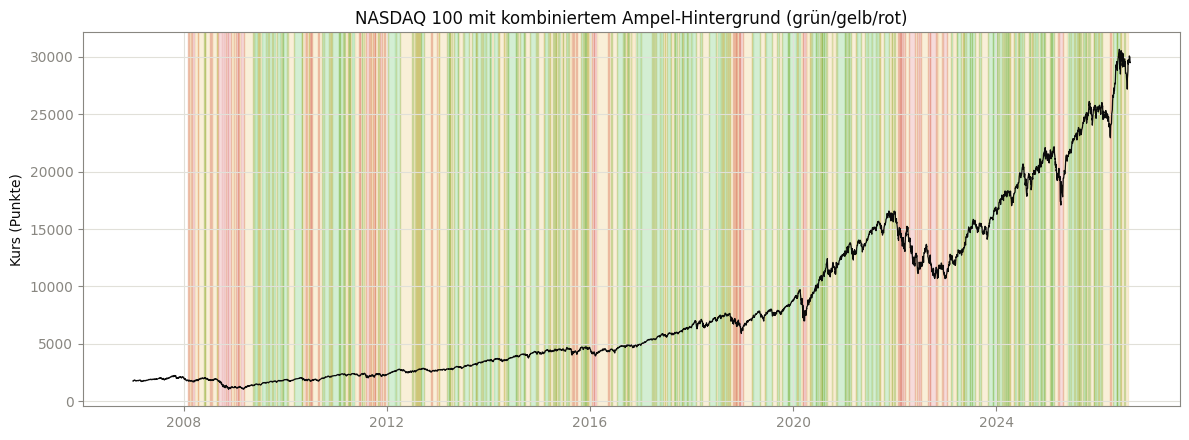

In [22]:
# --- Chart 1: Kursverlauf mit Ampel-Hintergrund ---
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in AMPEL_FARBEN:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=AMPEL_FARBCODES[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{cfg['name']} mit kombiniertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()

Der Kursverlauf zeigt die Ampelfarbe als Hintergrundfläche: Rot markiert
Phasen mit hohem Belastungsgrad (viele Kandidatensignale gleichzeitig
"schlecht"), Grün Phasen niedriger Belastung. Zur Einordnung lohnt sich der
Blick darauf, ob die roten Flächen tatsächlich mit den größeren, bekannten
Kurseinbrüchen zusammenfallen (z. B. 2008, 2020, 2022) — das ist die
visuelle Gegenprobe zur Zahlentabelle direkt darüber.


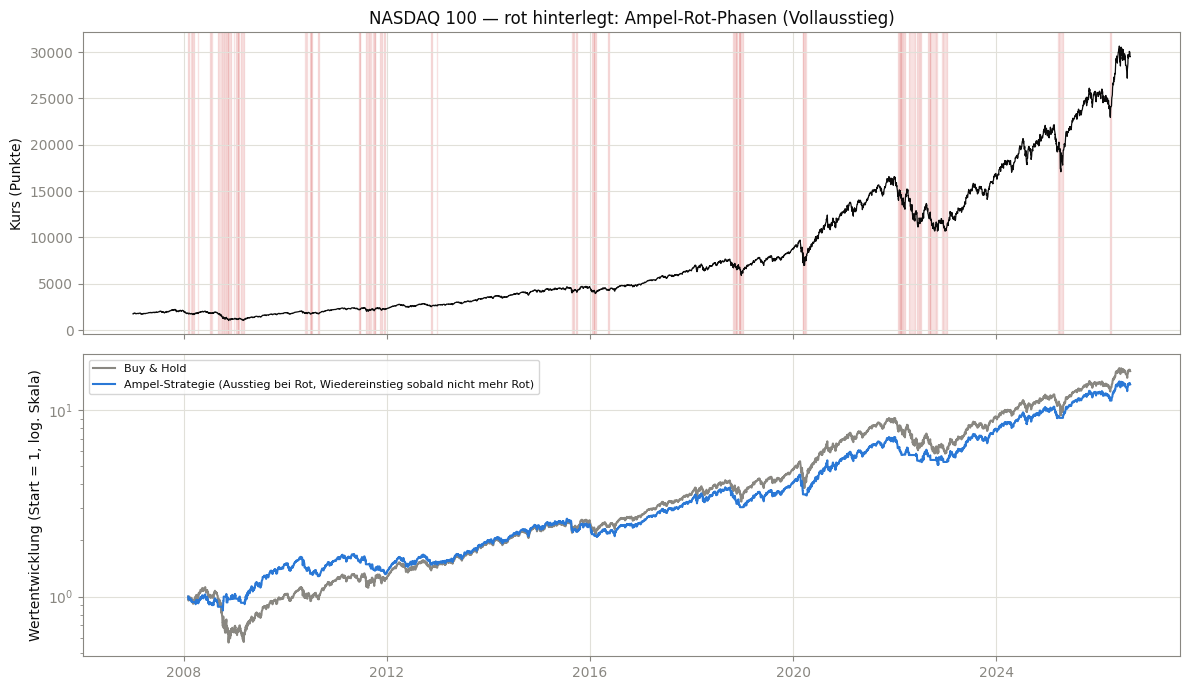

Anteil Rot-Handelstage: 9.3%
Gesamtrendite - Buy & Hold: 1514.3% | Ampel-Strategie: 1269.8%
CAGR          - Buy & Hold: 16.2% | Ampel-Strategie: 15.2%
Max Drawdown  - Buy & Hold: -49.6% | Ampel-Strategie: -29.2%


In [23]:
# --- Chart 2 + Kennzahlen: Was-wäre-wenn-Simulation ---
ergebnis_www = was_wäre_wenn(df, (df["Ampel"] == "Rot").where(df["Ampel"].notna()), f"{IDX_KEY}_Ampel_Rot")

fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
schlecht_reindiziert = (df["Ampel"] == "Rot").reindex(df.index).fillna(False)
achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                         transform=achse_kurs.get_xaxis_transform())
achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse_kurs.set_ylabel("Kurs (Punkte)")
achse_kurs.set_title(f"{cfg['name']} — rot hinterlegt: Ampel-Rot-Phasen (Vollausstieg)")

achse_equity.plot(ergebnis_www["equity_buy_hold"].index, ergebnis_www["equity_buy_hold"],
                   color=COLOR_MUTED, label="Buy & Hold")
achse_equity.plot(ergebnis_www["equity_strategie"].index, ergebnis_www["equity_strategie"], color=COLOR_A,
                   label="Ampel-Strategie (Ausstieg bei Rot, Wiedereinstieg sobald nicht mehr Rot)")
achse_equity.set_yscale("log")
achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse_equity.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Anteil Rot-Handelstage: {ergebnis_www['anteil_schlecht_tage']:.1%}")
print(f"Gesamtrendite - Buy & Hold: {ergebnis_www['gesamtrendite_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['gesamtrendite_strategie']:.1%}")
print(f"CAGR          - Buy & Hold: {ergebnis_www['cagr_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['cagr_strategie']:.1%}")
print(f"Max Drawdown  - Buy & Hold: {ergebnis_www['max_drawdown_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['max_drawdown_strategie']:.1%}")

Oben derselbe Kursverlauf, diesmal nur mit den Rot-Phasen hervorgehoben (in
denen die simulierte Strategie vollständig in Cash geht). Unten die daraus
resultierende Wertentwicklung im Vergleich zu Buy & Hold auf logarithmischer
Skala (damit prozentual gleich große Veränderungen unabhängig vom absoluten
Indexstand gleich groß erscheinen). Die drei Kennzahlen darunter —
Gesamtrendite, CAGR und Max Drawdown — fassen zusammen, ob und wie stark die
Ampel-Strategie den größten historischen Verlust gegenüber Buy & Hold
reduziert und was sie das im Gegenzug an Rendite gekostet oder gebracht hat.


In [24]:
# --- Konfiguration exportieren (für Notebook B "Einstiegssignale") ---
konfiguration = {
    "index": IDX_KEY, "name": cfg["name"],
    "signale": list(beste["signale"]),
    "grün_max": float(beste["grün_max"]), "rot_min": float(beste["rot_min"]),
}
with open(EXPORT_DIR / f"{IDX_KEY}_ampel_konfiguration.json", "w", encoding="utf-8") as f:
    json.dump(konfiguration, f, ensure_ascii=False, indent=2)

resultate[IDX_KEY] = {
    "cfg": cfg, "df": df, "beste": beste,
    "tabelle_validierung": tabelle_validierung,
    "was_wäre_wenn": {k: v for k, v in ergebnis_www.items() if k not in ("equity_buy_hold", "equity_strategie")},
    "konfiguration": konfiguration,
}
print(f"Konfiguration exportiert: {EXPORT_DIR / f'{IDX_KEY}_ampel_konfiguration.json'}")

Konfiguration exportiert: Hypothesenanalysen_Kombiniert\NASDAQ100_ampel_konfiguration.json


**Fazit NASDAQ 100:** Die oben gezeigte Kombination ist **dieselbe** wie in den
übrigen drei Indices — hier stehen nur die für NASDAQ 100 individuellen Kennzahlen
(Signifikanztabelle, Diagramme, Was-wäre-wenn-Kennzahlen). Details zur gewählten
Kombination selbst stehen einmalig in Abschnitt 4.0, die Out-of-Sample-Validierung
in Abschnitt 4.0.1: NASDAQ 100 bestätigt sich dort gut (Test-Calmar 0,69).

### 4.4 Russell 2000

In [25]:
IDX_KEY = "Russell2000"
cfg = index_daten[IDX_KEY]["cfg"]
df = index_daten[IDX_KEY]["df"]
bad_df = index_daten[IDX_KEY]["bad_df"]

grad = belastungsgrad(bad_df, beste["signale"])
df["Belastungsgrad"] = grad
df["Ampel"] = ampel_aus_belastungsgrad(grad, beste["grün_max"], beste["rot_min"])

print(f"Verteilung der Handelstage auf die drei Ampelfarben ({cfg['name']}):")
print(df["Ampel"].value_counts().reindex(AMPEL_FARBEN))

Verteilung der Handelstage auf die drei Ampelfarben (Russell 2000):
Ampel
Grün     980
Gelb    1833
Rot      396
Name: count, dtype: int64


In [26]:
# --- Statistische Validierung der gewählten Ampel ---
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]
ergebnisse_validierung = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgröße": ziel})
                ergebnisse_validierung.append(res)

tabelle_validierung = pd.DataFrame(ergebnisse_validierung)
display(tabelle_validierung[["vergleich", "horizont_tage", "zielgröße", "mean_a", "mean_b",
                              "t_pvalue", "u_pvalue", "signifikant_5pct"]])

,vergleich,horizont_tage,zielgröße,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0016,0.0130,0.0000,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0575,-0.0635,0.0004,0.1450,False
2,Grün vs. Gelb,60,fwd_return,0.0056,0.0249,0.0000,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0878,-0.0937,0.0184,0.0018,True
4,Grün vs. Gelb,90,fwd_return,0.0116,0.0381,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.1151,-0.1139,0.7049,0.3153,False
6,Gelb vs. Rot,30,fwd_return,0.0130,0.0331,0.0000,0.0001,True
7,Gelb vs. Rot,30,fwd_mdd,-0.0635,-0.0823,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0249,0.0589,0.0000,0.0000,True
9,Gelb vs. Rot,60,fwd_mdd,-0.0937,-0.1124,0.0000,0.0000,True


Die Tabelle zeigt für jedes Paar von Ampelfarben (Grün vs. Gelb, Gelb vs.
Rot, Grün vs. Rot) und jeden Zeithorizont (30/60/90 Tage), ob sich die
künftige Rendite (`fwd_return`) bzw. der künftige Max Drawdown (`fwd_mdd`)
nach Tagen dieser beiden Farben statistisch unterscheidet. `mean_a`/`mean_b`
sind die jeweiligen Durchschnittswerte, `t_pvalue`/`u_pvalue` die p-Werte
der beiden Tests aus Abschnitt 2, und `signifikant_5pct` ist `True`, wenn
beide Tests einen Unterschied auf dem 5-%-Niveau bestätigen. Je mehr Zeilen
mit `True` markiert sind und je klarer sich `mean_a`/`mean_b` in die
erwartete Richtung unterscheiden (Grün besser als Gelb besser als Rot),
desto stärker ist der Beleg, dass die Ampel für diesen Index tatsächlich
etwas über künftiges Risiko und künftige Rendite aussagt.


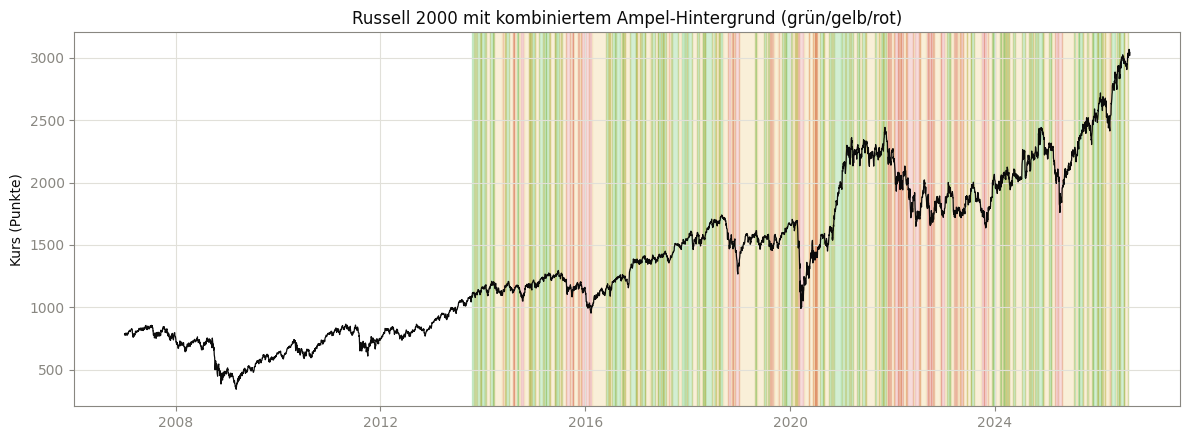

In [27]:
# --- Chart 1: Kursverlauf mit Ampel-Hintergrund ---
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in AMPEL_FARBEN:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=AMPEL_FARBCODES[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{cfg['name']} mit kombiniertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()

Der Kursverlauf zeigt die Ampelfarbe als Hintergrundfläche: Rot markiert
Phasen mit hohem Belastungsgrad (viele Kandidatensignale gleichzeitig
"schlecht"), Grün Phasen niedriger Belastung. Zur Einordnung lohnt sich der
Blick darauf, ob die roten Flächen tatsächlich mit den größeren, bekannten
Kurseinbrüchen zusammenfallen (z. B. 2008, 2020, 2022) — das ist die
visuelle Gegenprobe zur Zahlentabelle direkt darüber.


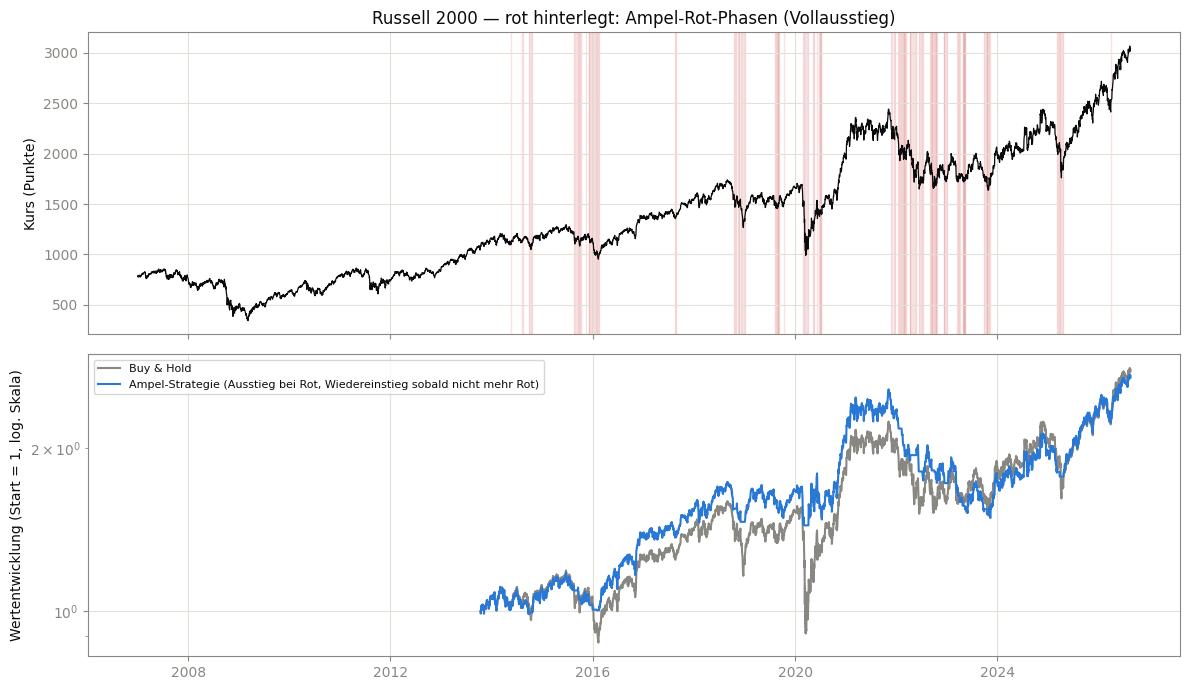

Anteil Rot-Handelstage: 12.3%
Gesamtrendite - Buy & Hold: 179.0% | Ampel-Strategie: 171.6%
CAGR          - Buy & Hold: 8.3% | Ampel-Strategie: 8.1%
Max Drawdown  - Buy & Hold: -43.1% | Ampel-Strategie: -42.1%


In [28]:
# --- Chart 2 + Kennzahlen: Was-wäre-wenn-Simulation ---
ergebnis_www = was_wäre_wenn(df, (df["Ampel"] == "Rot").where(df["Ampel"].notna()), f"{IDX_KEY}_Ampel_Rot")

fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
schlecht_reindiziert = (df["Ampel"] == "Rot").reindex(df.index).fillna(False)
achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                         transform=achse_kurs.get_xaxis_transform())
achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse_kurs.set_ylabel("Kurs (Punkte)")
achse_kurs.set_title(f"{cfg['name']} — rot hinterlegt: Ampel-Rot-Phasen (Vollausstieg)")

achse_equity.plot(ergebnis_www["equity_buy_hold"].index, ergebnis_www["equity_buy_hold"],
                   color=COLOR_MUTED, label="Buy & Hold")
achse_equity.plot(ergebnis_www["equity_strategie"].index, ergebnis_www["equity_strategie"], color=COLOR_A,
                   label="Ampel-Strategie (Ausstieg bei Rot, Wiedereinstieg sobald nicht mehr Rot)")
achse_equity.set_yscale("log")
achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse_equity.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Anteil Rot-Handelstage: {ergebnis_www['anteil_schlecht_tage']:.1%}")
print(f"Gesamtrendite - Buy & Hold: {ergebnis_www['gesamtrendite_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['gesamtrendite_strategie']:.1%}")
print(f"CAGR          - Buy & Hold: {ergebnis_www['cagr_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['cagr_strategie']:.1%}")
print(f"Max Drawdown  - Buy & Hold: {ergebnis_www['max_drawdown_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['max_drawdown_strategie']:.1%}")

Oben derselbe Kursverlauf, diesmal nur mit den Rot-Phasen hervorgehoben (in
denen die simulierte Strategie vollständig in Cash geht). Unten die daraus
resultierende Wertentwicklung im Vergleich zu Buy & Hold auf logarithmischer
Skala (damit prozentual gleich große Veränderungen unabhängig vom absoluten
Indexstand gleich groß erscheinen). Die drei Kennzahlen darunter —
Gesamtrendite, CAGR und Max Drawdown — fassen zusammen, ob und wie stark die
Ampel-Strategie den größten historischen Verlust gegenüber Buy & Hold
reduziert und was sie das im Gegenzug an Rendite gekostet oder gebracht hat.


In [29]:
# --- Konfiguration exportieren (für Notebook B "Einstiegssignale") ---
konfiguration = {
    "index": IDX_KEY, "name": cfg["name"],
    "signale": list(beste["signale"]),
    "grün_max": float(beste["grün_max"]), "rot_min": float(beste["rot_min"]),
}
with open(EXPORT_DIR / f"{IDX_KEY}_ampel_konfiguration.json", "w", encoding="utf-8") as f:
    json.dump(konfiguration, f, ensure_ascii=False, indent=2)

resultate[IDX_KEY] = {
    "cfg": cfg, "df": df, "beste": beste,
    "tabelle_validierung": tabelle_validierung,
    "was_wäre_wenn": {k: v for k, v in ergebnis_www.items() if k not in ("equity_buy_hold", "equity_strategie")},
    "konfiguration": konfiguration,
}
print(f"Konfiguration exportiert: {EXPORT_DIR / f'{IDX_KEY}_ampel_konfiguration.json'}")

Konfiguration exportiert: Hypothesenanalysen_Kombiniert\Russell2000_ampel_konfiguration.json


**Fazit Russell 2000:** Die oben gezeigte Kombination ist **dieselbe** wie in den
übrigen drei Indices — hier stehen nur die für Russell 2000 individuellen Kennzahlen
(Signifikanztabelle, Diagramme, Was-wäre-wenn-Kennzahlen). Details zur gewählten
Kombination selbst stehen einmalig in Abschnitt 4.0.

**Bekannte Einschränkung (siehe Abschnitt 4.0.1):** Anders als bei den übrigen drei
Indices bestätigt sich die Ampel für Russell 2000 im Out-of-Sample-Test ab 2020 nur
eingeschränkt — der Max Drawdown der Strategie liegt dort praktisch auf
Buy-&-Hold-Niveau. Ursache ist ein Whipsaw-Muster während der langgezogenen
Seitwärts-/Korrekturphase 2022/2023, nicht ein einzelner verpasster Crash (der
Corona-Crash 2020 wird weiterhin gut abgefedert). Bei der praktischen Nutzung der
Ampel für Russell 2000 sollte dies berücksichtigt werden.

## 5. Indexübergreifender Vergleich

Da alle vier Indices dieselbe Ampel-Definition (dieselben Signale, dieselben
Schwellenwerte) verwenden, zeigt dieser Abschnitt, wie unterschiedlich sich ein und
dieselbe Regel in vier unterschiedlichen Märkten historisch ausgewirkt hätte — das
ist der eigentliche Beleg für die Robustheit des gewählten Ansatzes, im Gegensatz zu
vier separat optimierten Einzellösungen. Für die Einordnung der Ergebnisse sind
zusätzlich die Out-of-Sample-Zahlen aus Abschnitt 4.0.1 heranzuziehen: Die hier
gezeigten Kennzahlen (Abschnitt 4.1-4.4) beziehen sich auf die volle Historie
inklusive der Trainingsdaten, auf denen die Kombination gesucht wurde, und sind
daher optimistischer als die unabhängige Testperiode.

In [30]:
zusammenfassung = []
for idx_key, r in resultate.items():
    b = r["beste"]
    w = r["was_wäre_wenn"]
    zusammenfassung.append({
        "Index": r["cfg"]["name"],
        "Signale": ", ".join(b["signale"]),
        "Anzahl Signale": b["n_signale"],
        "grün_max": b["grün_max"], "rot_min": b["rot_min"],
        "Anteil Rot": b[f"anteil_rot_{idx_key}"],
        "CAGR Buy&Hold": w["cagr_buy_hold"], "CAGR Strategie": w["cagr_strategie"],
        "MaxDD Buy&Hold": w["max_drawdown_buy_hold"], "MaxDD Strategie": w["max_drawdown_strategie"],
        "Calmar Strategie": w["cagr_strategie"] / abs(w["max_drawdown_strategie"]),
    })
tabelle_zusammenfassung = pd.DataFrame(zusammenfassung)
display(tabelle_zusammenfassung)

,Index,Signale,Anzahl Signale,grün_max,rot_min,Anteil Rot,CAGR Buy&Hold,CAGR Strategie,MaxDD Buy&Hold,MaxDD Strategie,Calmar Strategie
0,S&P 500,"H1_20, H1_100, H1_200, H2_20, H2_100, H3_20_20...",9,0.0000,0.7500,0.1104,0.0974,0.1167,-0.5258,-0.2040,0.5720
1,Dow Jones,"H1_20, H1_100, H1_200, H2_20, H2_100, H3_20_20...",9,0.0000,0.7500,0.0999,0.0810,0.1025,-0.4986,-0.2786,0.3678
2,NASDAQ 100,"H1_20, H1_100, H1_200, H2_20, H2_100, H3_20_20...",9,0.0000,0.7500,0.0866,0.1619,0.1516,-0.4956,-0.2923,0.5188
3,Russell 2000,"H1_20, H1_100, H1_200, H2_20, H2_100, H3_20_20...",9,0.0000,0.7500,0.0980,0.0831,0.0809,-0.4306,-0.4213,0.1920


Die Spalten "Signale", "grün_max" und "rot_min" sind in allen vier Zeilen
identisch — das ist beabsichtigt und der Kern der Umstellung auf einen
universellen Ansatz. Unterschiedlich sind dagegen "Anteil Rot", die CAGR-
und Max-Drawdown-Werte sowie der Calmar-Wert je Index: Sie zeigen, wie sich
dieselbe Ampel in jedem der vier Märkte historisch ausgewirkt hätte. Ein
durchgängig positiver Effekt (Strategie-Max-Drawdown kleiner als Buy & Hold,
bei weiterhin positiver Rendite) über alle vier Zeilen hinweg ist der
stärkste verfügbare Beleg für Robustheit.


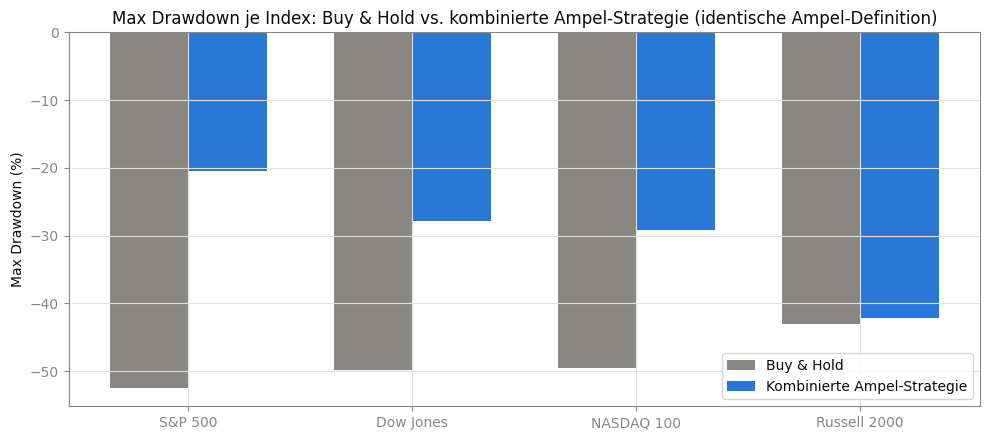

In [31]:
fig, achse = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(tabelle_zusammenfassung))
breite = 0.35
achse.bar(x - breite / 2, tabelle_zusammenfassung["MaxDD Buy&Hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_zusammenfassung["MaxDD Strategie"] * 100, breite,
          label="Kombinierte Ampel-Strategie", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_zusammenfassung["Index"])
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown je Index: Buy & Hold vs. kombinierte Ampel-Strategie (identische Ampel-Definition)")
plt.tight_layout()
plt.show()

Das Diagramm zeigt den historischen Max Drawdown je Index, einmal für Buy &
Hold (grau) und einmal für die Ampel-Strategie mit der oben gezeigten,
universellen Kombination (blau). Je deutlicher die blauen Balken kürzer sind
als die grauen, desto stärker hat die Ampel den größten Verlust in diesem
Index begrenzt — und zwar ohne dass die zugrunde liegende Regel an diesen
Index angepasst wurde.


## 6. Export der Ergebnisse

Die Ergebnisse werden in einer Excel-Arbeitsmappe sowie einzelnen CSV-Dateien
gespeichert. Besonders wichtig für den weiteren Projektverlauf sind die vier
`*_ampel_konfiguration.json`-Dateien (bereits in Abschnitt 4.1–4.4 geschrieben): Sie
enthalten die gewählte, gemeinsame Kombination und werden vom nachfolgenden
Notebook `Einstiegssignale.ipynb` eingelesen, ohne dass die Suche dort erneut
durchgeführt werden muss.

In [32]:
xlsx_pfad = EXPORT_DIR / "Risikoampel_Kombiniert_Zusammenfassung.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    tabelle_zusammenfassung.to_excel(writer, sheet_name="Zusammenfassung", index=False)
    universelle_tabelle.head(50).to_excel(writer, sheet_name="Universelle_Suche", index=False)
    for idx_key, r in resultate.items():
        r["tabelle_validierung"].to_excel(writer, sheet_name=f"{idx_key}_Validierung"[:31], index=False)

tabelle_zusammenfassung.to_csv(EXPORT_DIR / "Zusammenfassung.csv", index=False)
for idx_key, r in resultate.items():
    r["df"][["Close", "Belastungsgrad", "Ampel"]].to_csv(EXPORT_DIR / f"{idx_key}_Ampel_Zeitreihe.csv")

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print(f"Weitere CSV-Dateien im Ordner: {EXPORT_DIR.resolve()}")

Excel-Arbeitsmappe gespeichert: Hypothesenanalysen_Kombiniert\Risikoampel_Kombiniert_Zusammenfassung.xlsx
Weitere CSV-Dateien im Ordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt - final\Risikoampel Kombiniert\Hypothesenanalysen_Kombiniert


Damit stehen alle Ergebnisse sowohl als menschenlesbare Excel-Arbeitsmappe
(Übersichtstabelle, die zehn besten Kombinationen der universellen Suche,
Signifikanztabellen je Index) als auch als CSV-Dateien für eine mögliche
Weiterverarbeitung zur Verfügung.

## 7. Zusammenfassung

**Zentrale methodische Entscheidungen:**

- **Vier Indikator-Familien:** Der Kandidatenpool umfasst Trend, Marktbreite,
  Volatilität (index-eigener Vol-Index) und Sentiment (Put/Call-Ratio). Eine
  **Diversitäts-Pflicht** stellt sicher, dass jede geprüfte Kombination
  mindestens ein Signal aus Trend, Marktbreite und Volatilität enthält - eine
  ungefilterte Suche über den vollständigen Pool wählt sonst trotz
  verfügbarer Alternativen fast ausschließlich stark korrelierte
  Trend-Signale.
- **Mehrheit statt Einstimmigkeit:** Die Rot-Schwelle wird über ein Raster bis hinab
  zu 0,34 (knappe Mehrheit) mitgesucht, statt Einstimmigkeit vorauszusetzen.
- **Getrenntes Bewertungsfenster je Index:** Kombinationen mit später startenden
  Signalen (Marktbreite/Vol-Index beim Russell 2000) werden nur ab ihrem jeweils
  gemeinsam gültigen Zeitraum bewertet, nicht implizit als ungeschütztes Buy & Hold
  über die gesamte Vorperiode - das verhindert eine systematische Benachteiligung
  dieser Signale.
- **Train/Test-Split:** Die Kombination wird ausschließlich auf Daten bis Ende 2019
  gesucht und anschließend unverändert auf dem unabhängigen Zeitraum ab 2020 geprüft
  (Abschnitt 4.0.1) - ein Schutz vor Data-Snooping, der bei mehreren Zehntausend
  geprüften Kombinationen sonst real ein Risiko wäre.

**Gefundene Kombination:** `H1_20, H1_100, H1_200, H2_20, H2_100, H3_20_200, B1_20,
V1_Rot, S1_PCR_Extrem` (9 Signale aus allen vier Familien) bei `grün_max=0,0`,
`rot_min=0,75` (75-%-Mehrheit). Minimum-Calmar auf den Trainingsdaten: 0,40 - nahezu
doppelt so hoch wie bei einer rein SMA-basierten Kombination (0,21).

**Out-of-Sample-Ergebnis (Abschnitt 4.0.1, das eigentliche Qualitätskriterium):** Bei
S&P 500, Dow Jones und NASDAQ 100 bestätigt sich die Kombination auf dem
Testzeitraum ab 2020 deutlich - der Max Drawdown gegenüber Buy & Hold sinkt
durchgehend spürbar (z. B. S&P 500: -17 % statt -34 %), bei S&P 500 sogar mit einem
höheren Calmar als im Training. Bei **Russell 2000** bricht die Wirkung dagegen ein:
Der Corona-Crash 2020 wird weiterhin gut abgefedert, die langgezogene
Seitwärts-/Korrekturphase 2022/2023 führt jedoch zu einem Whipsaw-Muster
(wiederholtes Rot→Grün→Rot binnen weniger Tage), das den Drawdown-Schutz
zunichtemacht. Ein Test mit Mindesthaltedauer (Hysterese) als zusätzlichem, sauber
auf den Trainingsdaten gesuchtem Parameter zeigt: 0 Tage Mindesthaltedauer bleibt
optimal, da die Trainingsphase 2008-2019 überwiegend aus scharfen Trendbrüchen
bestand. Die Russell-2000-Schwäche 2022/2023 ist damit ein reales, im
Trainingszeitraum nicht vorgezeichnetes Marktregime, keine Kalibrierungsfrage - und
wird als dokumentierte, bekannte Einschränkung übernommen statt durch eine
Testdaten-Anpassung "wegoptimiert".

**Übergreifende Einordnung:** Die
erzwungene Diversität liefern eine Ampel, die tatsächlich mehrere Indikatorarten
kombiniert und sich für drei der vier Indices im echten Out-of-Sample-Test bewährt.
Die Grenzen dieses Ansatzes zeigen sich ehrlich bei Russell 2000: Eine einzelne,
für alle vier Märkte gemeinsame Regel kann nicht jedes marktspezifische Verhalten
abbilden, insbesondere nicht ein Regime (anhaltende relative Schwäche/Seitwärtsphase
bei Small Caps), für das die Trainingshistorie kein Vorbild bietet. 
